In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import spikeinterface as si
import matplotlib.pyplot as plt
import os
from matplotlib.backends.backend_pdf import PdfPages

from tqdm import tqdm


import sys
import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre


import torch.nn.functional as F
from pathlib import Path


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import time
import pickle
import networkx as nx
from probeinterface import write_probeinterface, read_probeinterface, Probe



In [3]:
def find_optimal_distance_threshold(probe, min_channels=26, max_channels=33, target_n_groups=5, 
                                     distance_range=(1000, 2000), step=50):
    """
    自动寻找最优的distance_threshold，使得产生的clique大小在指定范围内
    
    Parameters:
    -----------
    probe : Probe对象
        包含通道位置信息的probe对象
    min_channels : int
        每个组的最小通道数
    max_channels : int
        每个组的最大通道数
    target_n_groups : int
        目标组数量
    distance_range : tuple
        距离阈值搜索范围 (min, max)
    step : float
        搜索步长
    
    Returns:
    --------
    optimal_threshold : float
        最优的距离阈值
    """
    channel_positions = probe.contact_positions
    n_channels = len(channel_positions)
    
    print(f"\n=== 自动寻找最优distance_threshold ===")
    print(f"搜索范围: {distance_range[0]}-{distance_range[1]}μm, 步长: {step}μm")
    print(f"目标: 找到{target_n_groups}个clique，每个包含{min_channels}-{max_channels}个通道")
    
    best_threshold = None
    best_score = -1
    best_result = None
    
    for threshold in range(int(distance_range[0]), int(distance_range[1]) + 1, step):
        # 计算距离矩阵
        eps = 1e-5
        dist_matrix = np.linalg.norm(channel_positions[:, np.newaxis] - channel_positions, axis=2)
        np.fill_diagonal(dist_matrix, 0)
        dist_matrix[dist_matrix < eps] = eps
        
        # 构建邻接矩阵
        inv_dist = np.zeros_like(dist_matrix)
        inv_dist = np.where(dist_matrix > 0, 1, 0)
        np.fill_diagonal(inv_dist, 0)
        inv_dist[dist_matrix > threshold] = 0
        
        # 构建图并找到所有最大团
        graph = nx.from_numpy_array(inv_dist)
        maximal_cliques = list(nx.find_cliques(graph))
        
        # 筛选出满足通道数要求的clique
        valid_cliques = []
        for clique in maximal_cliques:
            if min_channels <= len(clique) <= max_channels:
                valid_cliques.append(clique)
        
        # 计算得分：优先选择clique数量接近target_n_groups，且大小分布均匀的
        if len(valid_cliques) >= target_n_groups:
            # 计算clique大小的方差（越小越好，表示大小均匀）
            clique_sizes = [len(c) for c in valid_cliques]
            size_variance = np.var(clique_sizes)
            
            # 得分：clique数量接近target_n_groups，且大小方差小
            score = target_n_groups / (abs(len(valid_cliques) - target_n_groups) + 1) - size_variance * 0.1
            
            if score > best_score:
                best_score = score
                best_threshold = threshold
                best_result = {
                    'threshold': threshold,
                    'n_cliques': len(maximal_cliques),
                    'n_valid_cliques': len(valid_cliques),
                    'clique_sizes': clique_sizes[:target_n_groups] if len(valid_cliques) >= target_n_groups else clique_sizes
                }
    
    if best_threshold is None:
        print("警告: 未找到满足条件的distance_threshold，使用默认值100μm")
        return 100.0, None
    
    print(f"\n找到最优distance_threshold: {best_threshold}μm")
    print(f"  总clique数: {best_result['n_cliques']}")
    print(f"  有效clique数: {best_result['n_valid_cliques']}")
    print(f"  前{target_n_groups}个clique的大小: {best_result['clique_sizes']}")
    
    return best_threshold, best_result

def create_channel_groups_using_cliques(probe, distance_threshold=None, min_channels=26, max_channels=33, target_n_groups=5):
    """
    使用clique方法根据probe位置创建通道组
    
    基于参考文件的方法：
    1. 计算通道之间的距离矩阵
    2. 构建图：如果两个通道距离 <= distance_threshold，则连接
    3. 找到所有最大团（clique）
    4. 筛选出满足通道数要求的clique
    5. 选择5个clique作为模型组
    
    Parameters:
    -----------
    probe : Probe对象
        包含通道位置信息的probe对象
    distance_threshold : float
        通道连接的距离阈值（单位：μm），如果为None则自动计算
    min_channels : int
        每个组的最小通道数，默认26
    max_channels : int
        每个组的最大通道数，默认33
    target_n_groups : int
        目标组数量，默认5
    
    Returns:
    --------
    dict: {group_id: {'channel_indices': [...], 'device_channel_indices': [...], 'n_channels': int, 'center': tuple}}
        组ID到通道信息的映射
    """
    # 如果distance_threshold未指定，自动计算
    if distance_threshold is None:
        distance_threshold, _ = find_optimal_distance_threshold(
            probe, min_channels, max_channels, target_n_groups
        )
    
    # 获取通道位置
    channel_positions = probe.contact_positions  # shape: (n_channels, 2)
    n_channels = len(channel_positions)
    
    print(f"\n=== 使用Clique方法创建通道组 ===")
    print(f"总通道数: {n_channels}")
    print(f"距离阈值: {distance_threshold}μm")
    print(f"目标组数: {target_n_groups}")
    print(f"每组通道数范围: {min_channels}-{max_channels}")
    
    # 计算距离矩阵
    eps = 1e-5
    dist_matrix = np.linalg.norm(channel_positions[:, np.newaxis] - channel_positions, axis=2)
    np.fill_diagonal(dist_matrix, 0)
    dist_matrix[dist_matrix < eps] = eps
    
    # 构建邻接矩阵：距离 <= threshold 的通道连接
    inv_dist = np.zeros_like(dist_matrix)
    inv_dist = np.where(dist_matrix > 0, 1, 0)
    np.fill_diagonal(inv_dist, 0)
    if distance_threshold is not None:
        inv_dist[dist_matrix > distance_threshold] = 0
    
    # 构建图并找到所有最大团
    graph = nx.from_numpy_array(inv_dist)
    maximal_cliques = list(nx.find_cliques(graph))
    
    print(f"找到 {len(maximal_cliques)} 个最大团")
    
    # 筛选出满足通道数要求的clique
    valid_cliques = []
    for clique in maximal_cliques:
        if min_channels <= len(clique) <= max_channels:
            valid_cliques.append(clique)
    
    print(f"满足通道数要求({min_channels}-{max_channels})的clique数量: {len(valid_cliques)}")
    
    if len(valid_cliques) < target_n_groups:
        print(f"警告: 满足要求的clique数量({len(valid_cliques)})少于目标组数({target_n_groups})")
        print("将使用所有满足要求的clique")
        target_n_groups = len(valid_cliques)
    
    # 选择clique：优先选择通道数接近平均值的，且位置分布均匀的
    # 计算每个clique的中心位置
    clique_centers = []
    for clique in valid_cliques:
        center = np.mean(channel_positions[clique], axis=0)
        clique_centers.append(center)
    
    clique_centers = np.array(clique_centers)
    
    # 使用贪心算法选择clique，确保覆盖所有channel
    all_channels = set(range(n_channels))
    covered_channels = set()
    selected_indices = []
    
    # 根据y坐标（深度）对clique进行排序，优先选择分布均匀的
    y_centers = clique_centers[:, 1]
    sorted_indices = np.argsort(y_centers)
    
    print(f"\n=== 使用贪心算法选择clique以确保覆盖所有channel和相邻重叠 ===")
    print(f"要求: 相邻clique之间至少有5个通道重叠")
    
    # 贪心选择：每次选择能覆盖最多未覆盖channel的clique，同时确保相邻重叠
    remaining_indices = sorted_indices.tolist()
    min_overlap = 5  # 最小重叠要求
    
    # 优先选择5个clique，尽量分布均匀且覆盖更多channel，同时确保相邻重叠
    for round_num in range(target_n_groups):
        if len(remaining_indices) == 0:
            break
        
        best_idx = None
        best_score = -1
        
        # 计算已选择clique的y坐标，用于确定相邻关系
        selected_y_centers = []
        for sel_idx in selected_indices:
            selected_y_centers.append(clique_centers[sel_idx][1])
        
        # 在所有剩余clique中选择
        for clique_idx in remaining_indices:
            clique = valid_cliques[clique_idx]
            new_channels = set(clique) - covered_channels
            
            # 计算与相邻clique的重叠
            current_y = clique_centers[clique_idx][1]
            overlap_with_adjacent = 0
            
            if len(selected_indices) > 0:
                # 找到最近的已选择clique（按y坐标）
                selected_clique_indices = []
                for sel_idx in selected_indices:
                    selected_clique_indices.append(sel_idx)
                
                # 计算与所有已选择clique的重叠，找出最大重叠
                max_overlap = 0
                for sel_idx in selected_indices:
                    selected_clique = valid_cliques[sel_idx]
                    overlap = len(set(clique) & set(selected_clique))
                    if overlap > max_overlap:
                        max_overlap = overlap
                
                overlap_with_adjacent = max_overlap
            else:
                # 第一个clique，不需要重叠
                overlap_with_adjacent = min_overlap
        
            # 评分：优先考虑重叠要求，然后考虑新覆盖
            # 如果已经有选择的clique，必须满足重叠要求
            if len(selected_indices) > 0:
                if overlap_with_adjacent < min_overlap:
                    # 不满足重叠要求，跳过
                    continue
                # 满足重叠要求，评分 = 重叠数 * 权重 + 新覆盖数
                score = overlap_with_adjacent * 0.5 + len(new_channels) * 1.0
            else:
                # 第一个clique，只考虑新覆盖
                score = len(new_channels) * 1.0
            
            if score > best_score:
                best_score = score
                best_idx = clique_idx
        
        if best_idx is not None:
            selected_indices.append(best_idx)
            clique = valid_cliques[best_idx]
            covered_channels.update(clique)
            remaining_indices.remove(best_idx)
            
            # 计算与相邻clique的重叠
            overlap_info = ""
            if len(selected_indices) > 1:
                overlaps = []
                for prev_idx in selected_indices[:-1]:
                    prev_clique = valid_cliques[prev_idx]
                    overlap = len(set(clique) & set(prev_clique))
                    overlaps.append(overlap)
                max_overlap = max(overlaps) if overlaps else 0
                overlap_info = f", 与已选clique最大重叠: {max_overlap}"
            
            print(f"第{round_num+1}轮: 选择clique {best_idx}, 新增{len(set(clique) - covered_channels)}个通道{overlap_info}, 累计覆盖{len(covered_channels)}/{n_channels}个通道")
        else:
            # 如果没有满足条件的clique，尝试放宽条件或选择重叠最大的
            if len(remaining_indices) > 0:
                # 如果已经有选择的clique，选择重叠最大的
                if len(selected_indices) > 0:
                    best_idx = None
                    best_overlap = -1
                    for clique_idx in remaining_indices:
                        clique = valid_cliques[clique_idx]
                        max_overlap = 0
                        for sel_idx in selected_indices:
                            selected_clique = valid_cliques[sel_idx]
                            overlap = len(set(clique) & set(selected_clique))
                            if overlap > max_overlap:
                                max_overlap = overlap
                        if max_overlap > best_overlap:
                            best_overlap = max_overlap
                            best_idx = clique_idx
                    
                    if best_idx is not None:
                        selected_indices.append(best_idx)
                        clique = valid_cliques[best_idx]
                        covered_channels.update(clique)
                        remaining_indices.remove(best_idx)
                        print(f"第{round_num+1}轮: 选择clique {best_idx} (重叠{best_overlap}, 不满足{min_overlap}要求), 累计覆盖{len(covered_channels)}/{n_channels}个通道")
                else:
                    # 第一个clique，随机选择
                    best_idx = remaining_indices[0]
                    selected_indices.append(best_idx)
                    clique = valid_cliques[best_idx]
                    covered_channels.update(clique)
                    remaining_indices.remove(best_idx)
                    print(f"第{round_num+1}轮: 选择clique {best_idx} (第一个), 累计覆盖{len(covered_channels)}/{n_channels}个通道")
    
    # 如果5个clique无法完全覆盖所有channel，继续添加clique
    if len(covered_channels) < n_channels:
        uncovered_channels = all_channels - covered_channels
        print(f"\n警告: 5个clique只覆盖了{len(covered_channels)}/{n_channels}个通道")
        print(f"未覆盖的通道数: {len(uncovered_channels)}")
        
        # 继续添加clique直到完全覆盖，同时尽量满足重叠要求
        extra_count = 0
        while len(covered_channels) < n_channels and len(remaining_indices) > 0:
            best_idx = None
            best_score = -1
            
            for clique_idx in remaining_indices:
                clique = valid_cliques[clique_idx]
                new_channels = set(clique) - covered_channels
                
                # 计算与已选择clique的重叠
                max_overlap = 0
                for sel_idx in selected_indices:
                    selected_clique = valid_cliques[sel_idx]
                    overlap = len(set(clique) & set(selected_clique))
                    if overlap > max_overlap:
                        max_overlap = overlap
                
                # 评分：优先考虑重叠（如果满足最小重叠要求），然后考虑新覆盖
                if max_overlap >= min_overlap:
                    score = max_overlap * 0.5 + len(new_channels) * 1.0
                else:
                    # 不满足重叠要求，但如果没有其他选择，仍然考虑
                    score = max_overlap * 0.1 + len(new_channels) * 1.0
                
                if score > best_score:
                    best_score = score
                    best_idx = clique_idx
            
            if best_idx is not None:
                selected_indices.append(best_idx)
                clique = valid_cliques[best_idx]
                covered_channels.update(clique)
                remaining_indices.remove(best_idx)
                extra_count += 1
                
                # 计算重叠信息
                max_overlap = 0
                for sel_idx in selected_indices[:-1]:
                    selected_clique = valid_cliques[sel_idx]
                    overlap = len(set(clique) & set(selected_clique))
                    if overlap > max_overlap:
                        max_overlap = overlap
                
                overlap_status = "✓" if max_overlap >= min_overlap else "✗"
                print(f"添加额外clique {best_idx} ({extra_count}): 新增{len(set(clique) - covered_channels)}个通道, 最大重叠{max_overlap} {overlap_status}, 累计覆盖{len(covered_channels)}/{n_channels}个通道")
            else:
                break
    
    # 检查是否完全覆盖
    if len(covered_channels) == n_channels:
        print(f"\n✓ 成功覆盖所有{n_channels}个通道！")
    else:
        uncovered_channels = all_channels - covered_channels
        print(f"\n✗ 警告: 仍有{len(uncovered_channels)}个通道未被覆盖")
        print(f"未覆盖的通道索引: {sorted(list(uncovered_channels))[:20]}..." if len(uncovered_channels) > 20 else f"未覆盖的通道索引: {sorted(list(uncovered_channels))}")
    
    # 检查重叠（按y坐标排序后检查相邻clique）
    print(f"\n=== 相邻clique重叠检查（按y坐标排序） ===")
    
    # 按y坐标对selected_indices排序
    selected_with_y = [(idx, clique_centers[idx][1]) for idx in selected_indices]
    selected_with_y.sort(key=lambda x: x[1])
    sorted_selected_indices = [x[0] for x in selected_with_y]
    
    # 重新创建groups字典，按照y坐标排序
    sorted_groups = {}
    for i, clique_idx in enumerate(sorted_selected_indices):
        clique = valid_cliques[clique_idx]
        group_id = f'model_{i+1}'
        group_device_channel_indices = [probe.device_channel_indices[idx] for idx in clique]
        center = clique_centers[clique_idx]
        
        sorted_groups[group_id] = {
            'channel_indices': list(clique),
            'device_channel_indices': group_device_channel_indices,
            'n_channels': len(clique),
            'center': tuple(center),
            'y_range': (channel_positions[clique, 1].min(), channel_positions[clique, 1].max())
        }
    
    groups = sorted_groups  # 使用排序后的groups
    
    # 打印结果
    print(f"\n选择的{len(groups)}个组（按y坐标排序）:")
    for group_id, group_info in groups.items():
        print(f"{group_id}: {group_info['n_channels']}个通道, "
              f"中心位置: ({group_info['center'][0]:.1f}, {group_info['center'][1]:.1f})μm, "
              f"y范围: {group_info['y_range'][0]:.1f}-{group_info['y_range'][1]:.1f}μm")
    
    # 检查相邻clique的重叠
    group_ids = list(groups.keys())
    min_overlap_required = 5
    all_satisfied = True
    
    for i in range(len(group_ids) - 1):
        group1 = groups[group_ids[i]]['device_channel_indices']
        group2 = groups[group_ids[i+1]]['device_channel_indices']
        overlap = len(set(group1) & set(group2))
        status = "✓" if overlap >= min_overlap_required else "✗"
        print(f"{group_ids[i]} 和 {group_ids[i+1]} 重叠: {overlap}个通道 {status}")
        if overlap < min_overlap_required:
            all_satisfied = False
    
    if all_satisfied:
        print(f"\n✓ 所有相邻clique之间的重叠都满足要求（≥{min_overlap_required}个通道）")
    else:
        print(f"\n✗ 警告: 部分相邻clique之间的重叠不满足要求（<{min_overlap_required}个通道）")
    
    # 检查所有组的并集是否覆盖所有channel
    all_group_channels = set()
    for group_info in groups.values():
        all_group_channels.update(group_info['channel_indices'])
    
    print(f"\n=== 覆盖检查 ===")
    print(f"所有组的并集包含: {len(all_group_channels)}个通道")
    print(f"总通道数: {n_channels}")
    if len(all_group_channels) == n_channels:
        print(f"✓ 所有通道都被覆盖！")
    else:
        missing_channels = set(range(n_channels)) - all_group_channels
        print(f"✗ 警告: 仍有{len(missing_channels)}个通道未被覆盖")
        print(f"未覆盖的通道索引: {sorted(list(missing_channels))[:20]}..." if len(missing_channels) > 20 else f"未覆盖的通道索引: {sorted(list(missing_channels))}")
    
    return groups

def plot_channel_groups(probe, channel_groups, output_pdf_path='channel_groups_visualization.pdf'):
    from matplotlib.patches import Rectangle
    
    channel_positions = probe.contact_positions
    channel_x = channel_positions[:, 0]
    channel_y = channel_positions[:, 1]
    

    if len(channel_x) > 1:
        x_spacing = np.min(np.diff(np.sort(np.unique(channel_x)))) if len(np.unique(channel_x)) > 1 else 20
        y_spacing = np.min(np.diff(np.sort(np.unique(channel_y)))) if len(np.unique(channel_y)) > 1 else 20
        # 电极应该是横着的（宽度>高度）
        rect_width = x_spacing * 0.8  # 宽度较大
        rect_height = y_spacing * 0.6  # 高度较小
    else:
        rect_width = 20
        rect_height = 8
    
    n_groups = len(channel_groups)
    # 调整figsize：高度大于宽度，每个子图宽度较小
    fig_width = 3 * n_groups  # 每个子图宽度3
    fig_height = 12  # 总高度12
    fig, axes = plt.subplots(1, n_groups, figsize=(fig_width, fig_height))
    
    # 减少子图之间的间距
    plt.subplots_adjust(left=0.002, right=0.98, top=0.95, bottom=0.05, wspace=0.02)
    
    if n_groups == 1:
        axes = [axes]
    
    all_group_channels = set()
    for group_info in channel_groups.values():
        all_group_channels.update(group_info['channel_indices'])
    
    # 计算坐标轴范围（添加边距）
    x_min, x_max = channel_x.min(), channel_x.max()
    y_min, y_max = channel_y.min(), channel_y.max()
    # 将x方向范围扩大2倍
    x_range = x_max - x_min
    x_center = (x_max + x_min) / 2
    x_min_expanded = x_center - x_range
    x_max_expanded = x_center + x_range
    x_margin = 0  # 不再需要额外的margin
    y_margin = (y_max - y_min) * 0.1 if (y_max - y_min) > 0 else 50
    
    for idx, (group_id, group_info) in enumerate(channel_groups.items()):
        ax = axes[idx]
        
        group_channel_indices = set(group_info['channel_indices'])
        
        red_count = 0
        gray_count = 0
        for ch_idx, (x, y) in enumerate(zip(channel_x, channel_y)):
            if ch_idx in group_channel_indices:
                color = '#ED7B85'  # 红色
                alpha = 0.9
                red_count += 1
            else:
                color = 'lightgrey'
                alpha = 0.4
                gray_count += 1
            
            rect = Rectangle((x - rect_width/2, y - rect_height/2), 
                            rect_width, rect_height,
                            facecolor=color, alpha=alpha, edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)
        
        
        ax.set_xlim(x_min_expanded, x_max_expanded)
        ax.set_ylim(y_min - y_margin, y_max + y_margin)
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(f'{group_id}\n({group_info["n_channels"]} channels)', 
                    fontsize=10, fontweight='bold', pad=5)
        ax.grid(False)  
        ax.set_xticks([])
        ax.set_yticks([])
    
    # 保存为PDF（不使用tight_layout，因为已经用subplots_adjust调整了）
    with PdfPages(output_pdf_path) as pdf:
        pdf.savefig(fig, bbox_inches='tight', pad_inches=0.1)
    
    print(f"\n通道组可视化PDF已保存至: {output_pdf_path}")
    plt.close()


In [4]:
def count_array2_in_range_of_array1(array1, array2, threshold=5):

    sorted_array1 = np.sort(array1)
    array2 = np.sort(array2)
    
    lefts = array2 - threshold
    rights = array2 + threshold
    
    left_indices = np.searchsorted(sorted_array1, lefts, side='left')
    
    right_indices = np.searchsorted(sorted_array1, rights, side='right')
    
    has_within_range = right_indices > left_indices
    
    count = np.sum(has_within_range)
    
    return count

def label_array1_based_on_array2(array1, array2, threshold=5):
    array_1 = np.sort(array1)
    sorted_array2 = np.sort(array2)
    
    labels = np.zeros(len(array1), dtype=int)
    
    for i, value in enumerate(array1):
        left = value - threshold
        right = value + threshold
        
        left_index = np.searchsorted(sorted_array2, left, side='left')
        right_index = np.searchsorted(sorted_array2, right, side='right')
        
        if right_index > left_index:
            labels[i] = 1
    
    return labels
def detect_local_maxima_in_window(data, window_size=20, std_multiplier=2):

    """
    在每个滑动窗口范围内检测局部最大值的索引，并确保最大值大于两倍的标准差。

    参数:
    data : numpy.ndarray
        输入数据，形状为 (n_rows, n_columns)。
    window_size : int
        滑动窗口的大小，用于定义局部范围，默认为 20。
    std_multiplier : float
        标准差的倍数，用于筛选局部最大值，默认为 2。

    返回:
    local_maxima_indices : list of numpy.ndarray
        每行局部最大值的索引列表，每个元素是对应行局部最大值的索引数组。
    """
    local_maxima_indices = []

    for row in data:
        maxima_indices = []
        row_std = np.std(row.astype(np.float32))
        threshold = std_multiplier * row_std

        for start in range(0, len(row), window_size):
            end = min(start + window_size, len(row))
            window = np.abs(row[start:end])
            
            if len(window) > 0:
                local_max_index = np.argmax(window)
                local_max_value = window[local_max_index]
                
                if local_max_value > threshold:
                    maxima_indices.append(start + local_max_index)  
        
        local_maxima_indices.extend(maxima_indices)
        local_maxima_indices = list(set(local_maxima_indices))  

    return local_maxima_indices


def cluster_label_array1_based_on_array2(array1, array2, threshold=5):
    """
    根据 array2 的时间与cluster信息，对 array1 中的时间点赋予对应的cluster标签。
    若在指定阈值范围内未找到匹配时间，则标签为0。
    """
    array1 = np.asarray(array1)
    labels = np.zeros(len(array1), dtype=int)
    if array2 is None or len(array2) == 0 or len(array1) == 0:
        return labels
    if hasattr(array2, 'columns'):
        time_column = None
        for col in ['time', 'sample_index']:
            if col in array2.columns:
                time_column = col
                break
        if time_column is None:
            # 回退到按列位置
            time_values = array2.iloc[:, 0].to_numpy()
        else:
            time_values = array2[time_column].to_numpy()
        cluster_column = None
        for col in ['cluster_id', 'cluster']:
            if col in array2.columns:
                cluster_column = col
                break
        if cluster_column is None:
            cluster_values = array2.iloc[:, 1].to_numpy()
        else:
            cluster_values = array2[cluster_column].to_numpy()
    else:
        array2 = np.asarray(array2)
        time_values = array2[:, 0]
        cluster_values = array2[:, 1]
    if len(time_values) == 0:
        return labels
    time_values = np.asarray(time_values)
    cluster_values = np.asarray(cluster_values)
    sorted_indices = np.argsort(time_values)
    sorted_times = time_values[sorted_indices]
    sorted_clusters = cluster_values[sorted_indices]
    for i, value in enumerate(array1):
        left = value - threshold
        right = value + threshold
        left_index = np.searchsorted(sorted_times, left, side='left')
        right_index = np.searchsorted(sorted_times, right, side='right')
        if right_index > left_index:
            try:
                labels[i] = int(sorted_clusters[left_index])
            except (ValueError, TypeError):
                labels[i] = 0
    return labels


def label_array1_based_on_array2(array1, array2, threshold=5):

    """
    根据 array2 的值对 array1 进行标记。
    如果 array1 中的某个值在 threshold 范围内存在于 array2 中，则标记为 1，否则为 0。
    
    参数:
    array1 : numpy.ndarray
        要标记的数组。
    array2 : numpy.ndarray
        用于判断的数组。
    threshold : int
        判断范围的阈值。
    
    返回:
    labels : numpy.ndarray
        长度为 len(array1) 的标签数组，值为 0 或 1。
    """
    # 对 array2 进行排序以加速搜索
    sorted_array2 = np.sort(array2)
    
    # 初始化标签数组，默认值为 0
    labels = np.zeros(len(array1), dtype=int)
    
    # 遍历 array1 中的每个元素
    for i, value in enumerate(array1):
        # 计算当前值的范围
        left = value - threshold
        right = value + threshold
        
        # 使用二分搜索判断范围内是否存在值
        left_index = np.searchsorted(sorted_array2, left, side='left')
        right_index = np.searchsorted(sorted_array2, right, side='right')
        
        # 如果范围内存在值，则标记为 1
        if right_index > left_index:
            labels[i] = 1
    
    return labels


def extract_windows(data, indices, window_size=61):
    """
    根据给定的时间点索引提取窗口。
    
    参数:
    data : numpy.ndarray
        输入数据，形状为 (n_channels, time)
    indices : numpy.ndarray
        时间点索引数组，用于指定需要提取窗口的中心点
    window_size : int
        窗口长度，默认为61（对应time-30到time+31）
    
    返回:
    windows : numpy.ndarray
        提取的窗口数据，形状为 (len(indices), n_channels, window_size)
    """
    n_channels, time_length = data.shape
    half_window = window_size // 2

    if np.any(indices < half_window) or np.any(indices >= time_length - half_window):
        raise ValueError("Some indices are out of bounds for the given window size.")

    windows = []
    for idx in indices:
        window = data[:, idx - half_window:idx + half_window + 1]
        windows.append(window)

    windows = np.array(windows)
    return windows

In [5]:
# UMAP可视化函数
from umap import UMAP
import matplotlib.patches as mpatches

def visualize_model_umap(model_id, model_dir, test_dataset, model, device='cuda', n_samples=100000, 
                         output_pdf_path=None, cluster_labels=None, kmeans_labels=None,
                         kmeans_neuron_labels=None, gt_alignment=None, pred_alignment=None):
    """
    对训练好的模型进行UMAP可视化，并支持额外的聚类/对齐子图。
    """
    model.eval()

    total_len = len(test_dataset)

    def _validate_length(name, arr):
        if arr is None:
            return None
        arr = np.asarray(arr)
        if len(arr) != total_len:
            print(f"警告: {name}长度({len(arr)})与数据集长度({total_len})不一致，忽略{name}绘图")
            return None
        return arr

    cluster_labels = _validate_length('cluster_labels', cluster_labels)
    kmeans_labels = _validate_length('kmeans_labels', kmeans_labels)
    kmeans_neuron_labels = _validate_length('kmeans_neuron_labels', kmeans_neuron_labels)
    gt_alignment = _validate_length('gt_alignment', gt_alignment)
    pred_alignment = _validate_length('pred_alignment', pred_alignment)

    sampled_cluster_labels = None
    sampled_kmeans_labels = None
    sampled_kmeans_neurons = None
    sampled_gt_alignment = None
    sampled_pred_alignment = None

    if total_len > n_samples:
        indices = np.random.choice(total_len, n_samples, replace=False)
        sampled_dataset = torch.utils.data.Subset(test_dataset, indices)
        sampled_loader = DataLoader(sampled_dataset, batch_size=batch_size, shuffle=False)
        if cluster_labels is not None:
            sampled_cluster_labels = cluster_labels[indices]
        if kmeans_labels is not None:
            sampled_kmeans_labels = kmeans_labels[indices]
        if kmeans_neuron_labels is not None:
            sampled_kmeans_neurons = kmeans_neuron_labels[indices]
        if gt_alignment is not None:
            sampled_gt_alignment = gt_alignment[indices]
        if pred_alignment is not None:
            sampled_pred_alignment = pred_alignment[indices]
    else:
        sampled_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        if cluster_labels is not None:
            sampled_cluster_labels = cluster_labels
        if kmeans_labels is not None:
            sampled_kmeans_labels = kmeans_labels
        if kmeans_neuron_labels is not None:
            sampled_kmeans_neurons = kmeans_neuron_labels
        if gt_alignment is not None:
            sampled_gt_alignment = gt_alignment
        if pred_alignment is not None:
            sampled_pred_alignment = pred_alignment

    print(f"\n=== {model_id} UMAP可视化 ===")
    print(f"采样数量: {min(n_samples, total_len)}")

    all_features = []
    all_labels_gt = []
    all_labels_pred = []
    collected_cluster_labels = [] if sampled_cluster_labels is not None else None
    collected_kmeans_labels = [] if sampled_kmeans_labels is not None else None
    collected_kmeans_neurons = [] if sampled_kmeans_neurons is not None else None
    collected_gt_alignment = [] if sampled_gt_alignment is not None else None
    collected_pred_alignment = [] if sampled_pred_alignment is not None else None
    start_idx = 0

    with torch.no_grad():
        for batch_data, batch_labels in sampled_loader:
            batch_size_curr = batch_data.shape[0]
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)

            features = model.extract_features(batch_data)
            all_features.append(features.cpu().numpy())

            outputs = model(batch_data)
            predicted = (outputs > 0.5).float().squeeze()
            all_labels_pred.append(predicted.cpu().numpy())
            all_labels_gt.append(batch_labels.cpu().numpy())

            if collected_cluster_labels is not None:
                collected_cluster_labels.append(sampled_cluster_labels[start_idx:start_idx + batch_size_curr])
            if collected_kmeans_labels is not None:
                collected_kmeans_labels.append(sampled_kmeans_labels[start_idx:start_idx + batch_size_curr])
            if collected_kmeans_neurons is not None:
                collected_kmeans_neurons.append(sampled_kmeans_neurons[start_idx:start_idx + batch_size_curr])
            if collected_gt_alignment is not None:
                collected_gt_alignment.append(sampled_gt_alignment[start_idx:start_idx + batch_size_curr])
            if collected_pred_alignment is not None:
                collected_pred_alignment.append(sampled_pred_alignment[start_idx:start_idx + batch_size_curr])
            start_idx += batch_size_curr

    all_features = np.concatenate(all_features, axis=0)
    all_labels_gt = np.concatenate(all_labels_gt, axis=0)
    all_labels_pred = np.concatenate(all_labels_pred, axis=0)

    def _stack(collected):
        if isinstance(collected, list) and len(collected) > 0:
            return np.concatenate(collected)
        return None

    collected_cluster_labels = _stack(collected_cluster_labels)
    collected_kmeans_labels = _stack(collected_kmeans_labels)
    collected_kmeans_neurons = _stack(collected_kmeans_neurons)
    collected_gt_alignment = _stack(collected_gt_alignment)
    collected_pred_alignment = _stack(collected_pred_alignment)

    if collected_cluster_labels is not None and len(collected_cluster_labels) != len(all_features):
        print("警告: cluster_labels采样长度与特征数量不匹配，跳过cluster子图")
        collected_cluster_labels = None
    if collected_kmeans_labels is not None and len(collected_kmeans_labels) != len(all_features):
        print("警告: kmeans_labels采样长度与特征数量不匹配，跳过kmeans子图")
        collected_kmeans_labels = None
    if collected_kmeans_neurons is not None and len(collected_kmeans_neurons) != len(all_features):
        print("警告: kmeans_neuron_labels采样长度与特征数量不匹配，跳过Neuron子图")
        collected_kmeans_neurons = None
    if collected_gt_alignment is not None and len(collected_gt_alignment) != len(all_features):
        print("警告: gt_alignment采样长度与特征数量不匹配，跳过Ground Truth对齐子图")
        collected_gt_alignment = None
    if collected_pred_alignment is not None and len(collected_pred_alignment) != len(all_features):
        print("警告: pred_alignment采样长度与特征数量不匹配，跳过预测对齐子图")
        collected_pred_alignment = None

    if collected_kmeans_neurons is not None:
        valid_neuron_mask = np.array([val not in (None, '') for val in collected_kmeans_neurons], dtype=bool)
        if not np.any(valid_neuron_mask):
            collected_kmeans_neurons = None

    print(f"提取的特征形状: {all_features.shape}")
    print(f"Ground truth标签分布: spike={np.sum(all_labels_gt==1)}, noise={np.sum(all_labels_gt==0)}")
    print(f"Predicted标签分布: spike={np.sum(all_labels_pred==1)}, noise={np.sum(all_labels_pred==0)}")

    print("进行UMAP降维...")
    umap_reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    umap_embedding = umap_reducer.fit_transform(all_features)

    has_cluster_plot = collected_cluster_labels is not None
    has_kmeans_plot = collected_kmeans_labels is not None
    has_kmeans_neuron_plot = collected_kmeans_neurons is not None
    has_gt_alignment_plot = collected_gt_alignment is not None
    has_pred_alignment_plot = collected_pred_alignment is not None

    n_subplots = 2
    if has_cluster_plot:
        n_subplots += 1
    if has_kmeans_neuron_plot:
        n_subplots += 1
    if has_kmeans_plot:
        n_subplots += 1
    if has_gt_alignment_plot:
        n_subplots += 1
    if has_pred_alignment_plot:
        n_subplots += 1

    fig, axes = plt.subplots(1, n_subplots, figsize=(6 * n_subplots, 6))
    axes = np.atleast_1d(axes)
    axes = list(axes)

    subplot_idx = 0

    ax_gt = axes[subplot_idx]
    subplot_idx += 1
    spike_mask_gt = all_labels_gt == 1
    noise_mask_gt = all_labels_gt == 0
    ax_gt.scatter(umap_embedding[noise_mask_gt, 0], umap_embedding[noise_mask_gt, 1],
                  c='lightgrey', alpha=1.0, s=0.1)
    ax_gt.scatter(umap_embedding[spike_mask_gt, 0], umap_embedding[spike_mask_gt, 1],
                  c='#FF8C42', alpha=1.0, s=0.1)
    ax_gt.set_title(f'{model_id} - Ground Truth', fontsize=14, fontweight='bold')

    ax_pred = axes[subplot_idx]
    subplot_idx += 1
    spike_mask_pred = all_labels_pred == 1
    noise_mask_pred = all_labels_pred == 0
    ax_pred.scatter(umap_embedding[noise_mask_pred, 0], umap_embedding[noise_mask_pred, 1],
                    c='lightgrey', alpha=1.0, s=0.1)
    ax_pred.scatter(umap_embedding[spike_mask_pred, 0], umap_embedding[spike_mask_pred, 1],
                    c='#FF8C42', alpha=1.0, s=0.1)
    ax_pred.set_title(f'{model_id} - Predicted Labels', fontsize=14, fontweight='bold')

    if has_cluster_plot:
        ax_cluster = axes[subplot_idx]
        subplot_idx += 1
        cluster_ids = collected_cluster_labels.astype(int)
        noise_mask = cluster_ids == 0
        unique_clusters = [cid for cid in np.unique(cluster_ids) if cid != 0]
        if np.any(noise_mask):
            ax_cluster.scatter(umap_embedding[noise_mask, 0], umap_embedding[noise_mask, 1],
                               c='lightgrey', alpha=1.0, s=0.1, label='Noise/0')
        if unique_clusters:
            cmap = plt.cm.get_cmap('tab20', len(unique_clusters))
            for idx, cid in enumerate(unique_clusters):
                mask = cluster_ids == cid
                ax_cluster.scatter(umap_embedding[mask, 0], umap_embedding[mask, 1],
                                   c=[cmap(idx)], alpha=1.0, s=0.1, label=f'Cluster {cid}')
            if len(unique_clusters) <= 12:
                ax_cluster.legend(fontsize=9, loc='best')
        ax_cluster.set_title(f'{model_id} - Cluster Labels', fontsize=14, fontweight='bold')

    if has_kmeans_neuron_plot:
        ax_kmeans_neuron = axes[subplot_idx]
        subplot_idx += 1
        neuron_ids = np.asarray(collected_kmeans_neurons, dtype=object)
        assigned_mask = np.array([(val is not None) and (val != '') for val in neuron_ids], dtype=bool)
        if np.any(~assigned_mask):
            ax_kmeans_neuron.scatter(umap_embedding[~assigned_mask, 0], umap_embedding[~assigned_mask, 1],
                                     s=0.1, alpha=0.5, color='#B0B0B0', label='未映射')
        unique_neurons = sorted({val for val in neuron_ids if val is not None and val != ''}, key=str)
        if unique_neurons:
            cmap_neuron = plt.cm.get_cmap('tab20', max(len(unique_neurons), 1))
            for idx, neuron in enumerate(unique_neurons):
                mask = neuron_ids == neuron
                ax_kmeans_neuron.scatter(umap_embedding[mask, 0], umap_embedding[mask, 1],
                                         s=0.1, alpha=0.9, color=cmap_neuron(idx % cmap_neuron.N), label=str(neuron))
            if len(unique_neurons) <= 12:
                ax_kmeans_neuron.legend(fontsize=8, loc='best', markerscale=4)
        ax_kmeans_neuron.set_title(f'{model_id} - KMeans Neuron', fontsize=14, fontweight='bold')

    if has_kmeans_plot:
        ax_kmeans = axes[subplot_idx]
        subplot_idx += 1
        kmeans_ids = collected_kmeans_labels.astype(int)
        unique_kmeans = np.unique(kmeans_ids)
        cmap_pred = plt.cm.get_cmap('tab20', max(len(unique_kmeans), 1))
        for idx, cid in enumerate(unique_kmeans):
            mask = kmeans_ids == cid
            if cid < 0:
                color = '#B0B0B0'
                label = 'KMeans: unmapped'
            else:
                color = cmap_pred(idx % cmap_pred.N)
                label = f'KMeans: {cid}'
            ax_kmeans.scatter(umap_embedding[mask, 0], umap_embedding[mask, 1],
                              s=0.1, alpha=0.9, color=color, label=label)
        if len(unique_kmeans) <= 12:
            ax_kmeans.legend(fontsize=8, loc='best', markerscale=4)
        ax_kmeans.set_title(f'{model_id} - KMeans Cluster', fontsize=14, fontweight='bold')

    if has_gt_alignment_plot:
        ax_gt_align = axes[subplot_idx]
        subplot_idx += 1
        gt_align = collected_gt_alignment.astype(int)
        aligned_mask = gt_align == 1
        unaligned_mask = gt_align != 1
        if np.any(unaligned_mask):
            ax_gt_align.scatter(umap_embedding[unaligned_mask, 0], umap_embedding[unaligned_mask, 1],
                                s=0.1, alpha=0.5, color='#B0B0B0', label='未对齐')
        if np.any(aligned_mask):
            ax_gt_align.scatter(umap_embedding[aligned_mask, 0], umap_embedding[aligned_mask, 1],
                                s=0.1, alpha=0.9, color='#FF8C00', label='已对齐')
        if len(ax_gt_align.collections) <= 2:
            ax_gt_align.legend(fontsize=8, loc='best', markerscale=4)
        ax_gt_align.set_title(f'{model_id} - Ground Truth Alignment', fontsize=14, fontweight='bold')

    if has_pred_alignment_plot:
        ax_pred_align = axes[subplot_idx]
        pred_align = collected_pred_alignment.astype(int)
        aligned_mask = pred_align == 1
        unaligned_mask = pred_align != 1
        if np.any(unaligned_mask):
            ax_pred_align.scatter(umap_embedding[unaligned_mask, 0], umap_embedding[unaligned_mask, 1],
                                   s=0.1, alpha=0.5, color='#B0B0B0', label='未对齐')
        if np.any(aligned_mask):
            ax_pred_align.scatter(umap_embedding[aligned_mask, 0], umap_embedding[aligned_mask, 1],
                                   s=0.1, alpha=0.9, color='#FF8C00', label='已对齐')
        if len(ax_pred_align.collections) <= 2:
            ax_pred_align.legend(fontsize=8, loc='best', markerscale=4)
        ax_pred_align.set_title(f'{model_id} - Predicted Alignment', fontsize=14, fontweight='bold')

    for ax in axes:
        ax.set_aspect('equal', adjustable='box')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')

    plt.tight_layout()

    if output_pdf_path is None:
        output_pdf_path = os.path.join(model_dir, f'{model_id}_umap_visualization.pdf')

    with PdfPages(output_pdf_path) as pdf:
        pdf.savefig(fig, bbox_inches='tight')

    print(f"UMAP可视化PDF已保存至: {output_pdf_path}")
    plt.close()

    return umap_embedding, all_labels_gt, all_labels_pred


In [6]:
# 加载probe_4的probe信息
from scipy.io import loadmat

probe_data = loadmat("/media/ubuntu/sda/duan/rat/probe/chanMapQPX_mice1.mat")
probe_x = probe_data['xcoords']
probe_y = probe_data['ycoords']

probe_position = pd.DataFrame(probe_x)
probe_position[1] = probe_y

probe_4 = Probe()
probe_4.set_contacts(positions=probe_position, contact_ids=probe_data['chanMap'][:, 0])
probe_4.set_device_channel_indices(range(128))

# print(f"已加载probe_4的recording数据")
# print(f"通道数: {recording_f.get_num_channels()}")
# print(f"采样率: {recording_f.get_sampling_frequency()} Hz")
# print(f"总帧数: {recording_f.get_num_samples()}")

# 使用clique方法创建5个重叠的通道组
channel_groups = create_channel_groups_using_cliques(
    probe=probe_4,
    distance_threshold=None,
    min_channels=20,
    max_channels=27,
    target_n_groups=7
)

# 将channel_groups转换为类似best_channels_group_dict的格式，用于后续处理
model_channel_dict = {}
for model_id, group_info in channel_groups.items():
    # 使用device_channel_indices作为通道标识
    channel_tuple = tuple(sorted(group_info['device_channel_indices']))
    # 为每个model分配一个唯一的cluster_id（这里使用model编号）
    model_channel_dict[channel_tuple] = [int(model_id.split('_')[1])]  # 提取model编号

print(f"\n创建了{len(model_channel_dict)}个模型组")



=== 自动寻找最优distance_threshold ===
搜索范围: 1000-2000μm, 步长: 50μm
目标: 找到7个clique，每个包含20-27个通道

找到最优distance_threshold: 1050μm
  总clique数: 102
  有效clique数: 102
  前7个clique的大小: [27, 27, 27, 27, 27, 27, 27]

=== 使用Clique方法创建通道组 ===
总通道数: 128
距离阈值: 1050μm
目标组数: 7
每组通道数范围: 20-27
找到 102 个最大团
满足通道数要求(20-27)的clique数量: 102

=== 使用贪心算法选择clique以确保覆盖所有channel和相邻重叠 ===
要求: 相邻clique之间至少有5个通道重叠
第1轮: 选择clique 9, 新增0个通道, 累计覆盖27/128个通道
第2轮: 选择clique 2, 新增0个通道, 与已选clique最大重叠: 5, 累计覆盖49/128个通道
第3轮: 选择clique 47, 新增0个通道, 与已选clique最大重叠: 5, 累计覆盖71/128个通道
第4轮: 选择clique 66, 新增0个通道, 与已选clique最大重叠: 5, 累计覆盖93/128个通道
第5轮: 选择clique 88, 新增0个通道, 与已选clique最大重叠: 5, 累计覆盖115/128个通道
第6轮: 选择clique 101, 新增0个通道, 与已选clique最大重叠: 14, 累计覆盖128/128个通道
第7轮: 选择clique 10, 新增0个通道, 与已选clique最大重叠: 26, 累计覆盖128/128个通道

✓ 成功覆盖所有128个通道！

=== 相邻clique重叠检查（按y坐标排序） ===

选择的7个组（按y坐标排序）:
model_1: 27个通道, 中心位置: (24.1, 507.8)μm, y范围: 0.0-1015.6μm
model_2: 27个通道, 中心位置: (25.9, 546.9)μm, y范围: 39.1-1054.7μm
model_3: 27个通道, 中心位置: (24.1, 1367.2)μm, y范围: 859.4

In [7]:
figure_dir = '/media/ubuntu/sda/duan/rat/figure'
os.makedirs(figure_dir, exist_ok=True)
pdf_path = f'{figure_dir}/probe_4_channel_groups_clique6.pdf'
plot_channel_groups(probe_4, channel_groups, output_pdf_path=pdf_path)


通道组可视化PDF已保存至: /media/ubuntu/sda/duan/rat/figure/probe_4_channel_groups_clique6.pdf


In [7]:
recording_raw_path = '/home/ubuntu/Downloads/paper/20250612_1.group0.bin'  # 根据实际路径调整
recording_raw = se.read_binary(recording_raw_path, sampling_frequency=30000, dtype=np.int16, num_channels=128*7)
probe_4_channel_offset = 128 * 3  # probe_4是第4组，索引为3
probe_4_channel_indices = [channel + probe_4_channel_offset for channel in range(128)]
recording_probe4_raw = recording_raw.select_channels(probe_4_channel_indices)
recording_probe4 = spre.bandpass_filter(recording_probe4_raw, freq_min=300, freq_max=3000)
recording_probe4 = spre.notch_filter(recording_probe4, freq=50)
recording_f = spre.common_reference(recording_probe4, reference="global", operator="median")
recording_f = recording_f.set_probegroup(probe_4)


In [10]:
class SpikeDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]
    

class Spike_Detection_MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size, n_channels, time_window):
        super(Spike_Detection_MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, 16)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(16, output_size)
        self.sigmoid = nn.Sigmoid()  

        self.n_channels = n_channels
        self.time_window = time_window

    def forward(self, x):
        x = x.reshape(-1, self.n_channels * self.time_window)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        x = self.sigmoid(x)
        return x
    
    def extract_features(self, x):
        """
        提取fc3层（relu3之后）的特征
        用于降维可视化
        """
        x = x.reshape(-1, self.n_channels * self.time_window)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)  # fc3的输出，经过relu3激活
        return x




In [11]:
class SpikeClassificationDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]


class Spike_Classification_MLP(nn.Module):
    """Two-layer classifier on detection embeddings."""

    def __init__(self, input_size: int, num_classes: int):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc_out = nn.Linear(32, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() > 2:
            x = x.reshape(x.size(0), -1)
        else:
            x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc_out(x)


In [ ]:
# 将所有clique的数据合并后训练单一模型
from collections import Counter
print("=== 开始处理probe_4的所有clique ===")
print(f"总共需要处理 {len(model_channel_dict)} 个模型组")

spike_inf_probe4 = pd.read_csv("/media/ubuntu/sda/duan/rat/sorting_results/day1/spike_inf.tsv_probe_4", index_col=0, sep='\t')
cluster_inf_probe4 = pd.read_csv("/media/ubuntu/sda/duan/rat/sorting_results/day1/cluster_inf_probe_4.csv", index_col=0)

main_result_dir = '/media/ubuntu/sda/duan/rat/spike_detection_results'
os.makedirs(main_result_dir, exist_ok=True)
combined_dir = os.path.join(main_result_dir, 'combined_model')
os.makedirs(combined_dir, exist_ok=True)

hidden_size1 = 512
hidden_size2 = 256
output_size = 1
device = 'cuda'
num_epochs = 50
batch_size = 1024
window_size = 71
half_window = window_size // 2
chunk_size = 120000

total_frames = recording_f.get_num_samples()
print(f"检测到recording总帧数: {total_frames}")

combined_windows = []
combined_labels = []
combined_clusters = []
clique_stats = []

for idx, (channels_tuple, model_ids) in enumerate(model_channel_dict.items()):
    model_id = f"model_{model_ids[0]}"
    print(f"\n{'='*80}")
    print(f"处理第 {idx+1}/{len(model_channel_dict)} 个clique: {model_id}")
    print(f"{'='*80}")

    try:
        group_info = channel_groups[model_id]
        channel_indices = group_info['channel_indices']
        clique_center = group_info['center']

        if 'position_1' in cluster_inf_probe4.columns and 'position_2' in cluster_inf_probe4.columns:
            from scipy.spatial import ConvexHull
            from matplotlib.path import Path

            clique_channel_positions = probe_4.contact_positions[channel_indices]
            if len(clique_channel_positions) >= 3:
                hull = ConvexHull(clique_channel_positions)
                hull_points = clique_channel_positions[hull.vertices]
                hull_path = Path(hull_points)
                cluster_positions = cluster_inf_probe4[['position_1', 'position_2']].values
                is_inside = hull_path.contains_points(cluster_positions)
                clusters_in_clique = cluster_inf_probe4[is_inside]
            else:
                x_min, x_max = clique_channel_positions[:, 0].min(), clique_channel_positions[:, 0].max()
                y_min, y_max = clique_channel_positions[:, 1].min(), clique_channel_positions[:, 1].max()
                cluster_positions = cluster_inf_probe4[['position_1', 'position_2']].values
                is_inside = ((cluster_positions[:, 0] >= x_min) & (cluster_positions[:, 0] <= x_max) &
                             (cluster_positions[:, 1] >= y_min) & (cluster_positions[:, 1] <= y_max))
                clusters_in_clique = cluster_inf_probe4[is_inside]
        else:
            clusters_in_clique = cluster_inf_probe4

        cluster_ids_in_clique = clusters_in_clique['cluster_id'].astype(int).tolist()
        valid_channels = [recording_f.channel_ids[ch_idx] for ch_idx in channel_indices if ch_idx < len(recording_f.channel_ids)]
        if not valid_channels:
            print("警告: 无可用通道，跳过")
            continue

        print(f"Clique中心位置: ({clique_center[0]:.1f}, {clique_center[1]:.1f}) μm")
        print(f"通道数量: {len(valid_channels)}")
        print(f"候选cluster数量: {len(cluster_ids_in_clique)}")

        all_valid_indices = []
        all_windows = []

        for start_frame in tqdm(range(0, total_frames, chunk_size), desc=f"{model_id} chunks"):
            end_frame = min(start_frame + chunk_size, total_frames)
            try:
                data_chunk = recording_f.get_traces(start_frame=start_frame,
                                                    end_frame=end_frame,
                                                    channel_ids=valid_channels)
                threshold_result = detect_local_maxima_in_window(
                    data_chunk.T, std_multiplier=3, window_size=30)
                threshold_result = np.array(threshold_result) + start_frame
                valid_indices = threshold_result[
                    (threshold_result >= start_frame + half_window + 1) &
                    (threshold_result < end_frame - half_window)
                ]
                for idx_val in valid_indices:
                    rel_idx = idx_val - start_frame
                    window = data_chunk.T[:, rel_idx-half_window:rel_idx+half_window+1]
                    all_windows.append(window)
                all_valid_indices.extend(valid_indices)
            except Exception as e:
                print(f"处理chunk时出错: {e}")
                continue

        all_valid_indices = np.array(all_valid_indices)
        all_windows = np.stack(all_windows) if len(all_windows) > 0 else np.array([])
        print(f"检测到的候选数量: {len(all_valid_indices):,}")

        cluster_col_name = None
        for col in ['cluster', 'cluster_id']:
            if col in spike_inf_probe4.columns:
                cluster_col_name = col
                break
        if cluster_col_name is None:
            spike_inf_temp = spike_inf_probe4.copy()
        elif cluster_ids_in_clique:
            spike_inf_temp = spike_inf_probe4[spike_inf_probe4[cluster_col_name].isin(cluster_ids_in_clique)].copy()
        else:
            spike_inf_temp = spike_inf_probe4.copy()

        if len(spike_inf_temp) == 0 or len(all_windows) == 0:
            print("警告: 无可用训练数据，跳过")
            continue

        labels = label_array1_based_on_array2(all_valid_indices, spike_inf_temp['time'], threshold=2)
        cluster_labels_full = cluster_label_array1_based_on_array2(all_valid_indices, spike_inf_temp, threshold=2)
        cluster_labels_full = np.asarray(cluster_labels_full, dtype=int)

        indices_0 = np.where(labels == 0)[0]
        indices_1 = np.where(labels == 1)[0]
        target_0_count = len(indices_1) * 3
        sampled_indices_0 = np.random.choice(indices_0, target_0_count, replace=False) if len(indices_0) > target_0_count else indices_0
        final_indices = np.concatenate([sampled_indices_0, indices_1])
        np.random.shuffle(final_indices)

        sampled_windows = all_windows[final_indices]
        sampled_labels = labels[final_indices]
        sampled_clusters = cluster_labels_full[final_indices]

        if len(final_indices) > 0:
            rng = np.random.default_rng(42 + idx)
            sample_count = max(1, int(len(final_indices) * 0.5))
            sampled_idx = rng.choice(len(final_indices), size=sample_count, replace=False)
            sampled_windows = sampled_windows[sampled_idx]
            sampled_labels = sampled_labels[sampled_idx]
            sampled_clusters = sampled_clusters[sampled_idx]

        combined_windows.append(sampled_windows)
        combined_labels.append(sampled_labels)
        combined_clusters.append(sampled_clusters)

        clique_stats.append({
            'model_id': model_id,
            'candidates': len(all_valid_indices),
            'positive': int(np.sum(labels == 1)),
            'samples_added': len(sampled_windows)
        })

    except Exception as e:
        print(f"✗ 处理 {model_id} 失败: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*80}")
print("数据收集完成")
print(f"成功收集 {len(combined_windows)} 个clique的数据")

if not combined_windows:
    raise RuntimeError("未收集到任何训练样本，无法训练模型。")

combined_windows = np.concatenate(combined_windows, axis=0)
combined_labels = np.concatenate(combined_labels, axis=0)
combined_clusters = np.concatenate(combined_clusters, axis=0)

print(f"组合后的样本总数: {combined_windows.shape[0]:,}")
print(f"正样本数量: {np.sum(combined_labels==1):,}")
print(f"负样本数量: {np.sum(combined_labels==0):,}")

input_size = combined_windows.shape[1] * combined_windows.shape[2]
model = Spike_Detection_MLP(input_size, hidden_size1, hidden_size2,
                            output_size, n_channels=combined_windows.shape[1], time_window=combined_windows.shape[2])
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.BCELoss()

dataset = SpikeDataset(combined_windows, combined_labels)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集大小: {train_size:,} ({train_size/len(dataset)*100:.1f}%)")
print(f"测试集大小: {test_size:,} ({test_size/len(dataset)*100:.1f}%)")

print(f"\n--- 开始训练统一模型 ---")
training_history = []
best_tpr = 0
patience = 5
patience_counter = 0
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for batch_data, batch_labels in train_loader:
        batch_labels = batch_labels.float().unsqueeze(1)
        batch_data = batch_data.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_data)
        loss = criterion(outputs, batch_labels)

        predicted = (outputs > 0.5).float()
        train_total += batch_labels.size(0)
        train_correct += (predicted == batch_labels).sum().item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    test_correct = 0
    test_total = 0
    true_positive = 0
    true_negative = 0
    false_positive = 0
    false_negative = 0

    with torch.no_grad():
        for batch_data, batch_labels in test_loader:
            batch_labels = batch_labels.float().unsqueeze(1)
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_data)
            predicted = (outputs > 0.5).float()
            test_total += batch_labels.size(0)
            test_correct += (predicted == batch_labels).sum().item()

            true_positive += ((predicted == 1) & (batch_labels == 1)).sum().item()
            true_negative += ((predicted == 0) & (batch_labels == 0)).sum().item()
            false_positive += ((predicted == 1) & (batch_labels == 0)).sum().item()
            false_negative += ((predicted == 0) & (batch_labels == 1)).sum().item()

    tpr = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0
    tnr = true_negative / (true_negative + false_positive) if (true_negative + false_positive) > 0 else 0
    accuracy = test_correct / test_total if test_total > 0 else 0

    if tpr > best_tpr:
        best_tpr = tpr
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        if epoch % 5 == 0 or epoch < 5:
            print(f"Epoch {epoch+1:3d}/{num_epochs}: ✓ 新最佳! TPR={tpr:.4f}, TNR={tnr:.4f}, Acc={accuracy:.4f}, Loss={train_loss/len(train_loader):.4f}")
    else:
        patience_counter += 1
        if epoch % 5 == 0 or epoch < 5:
            print(f"Epoch {epoch+1:3d}/{num_epochs}: TPR={tpr:.4f} (最佳: {best_tpr:.4f}), TNR={tnr:.4f}, Acc={accuracy:.4f}, 早停: {patience_counter}/{patience}")

    training_history.append({
        'epoch': epoch,
        'train_loss': train_loss / len(train_loader),
        'train_accuracy': train_correct / train_total if train_total > 0 else 0,
        'test_accuracy': accuracy,
        'tpr': tpr,
        'tnr': tnr,
        'patience_counter': patience_counter
    })

    if patience_counter >= patience:
        print("\n--- 早停触发 ---")
        print(f"连续 {patience} 个epoch没有提升，在第 {epoch+1} 个epoch停止训练")
        print(f"最佳TPR: {best_tpr:.4f}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
torch.save(model.state_dict(), os.path.join(combined_dir, 'best_model.pth'))

with open(os.path.join(combined_dir, 'training_history.pkl'), 'wb') as f:
    pickle.dump(training_history, f)
with open(os.path.join(combined_dir, 'clique_stats.pkl'), 'wb') as f:
    pickle.dump(clique_stats, f)

print(f"\n训练完成，最佳TPR: {best_tpr:.4f}")
print(f"模型已保存到: {combined_dir}")


=== 开始处理probe_4的所有clique ===
总共需要处理 7 个模型组
检测到recording总帧数: 19285560

处理第 1/7 个clique: model_1
Clique中心位置: (24.1, 507.8) μm
通道数量: 27
候选cluster数量: 22


model_1 chunks: 100%|██████████| 161/161 [02:14<00:00,  1.19it/s]


检测到的候选数量: 1,320,039

处理第 2/7 个clique: model_2
Clique中心位置: (25.9, 546.9) μm
通道数量: 27
候选cluster数量: 24


model_2 chunks: 100%|██████████| 161/161 [02:11<00:00,  1.23it/s]


检测到的候选数量: 1,392,006

处理第 3/7 个clique: model_3
Clique中心位置: (24.1, 1367.2) μm
通道数量: 27
候选cluster数量: 17


...

model_6 chunks: 100%|██████████| 161/161 [02:10<00:00,  1.24it/s]


检测到的候选数量: 1,107,216

处理第 7/7 个clique: model_7
Clique中心位置: (25.9, 4453.1) μm
通道数量: 27
候选cluster数量: 15


model_7 chunks: 100%|██████████| 161/161 [02:08<00:00,  1.26it/s]


检测到的候选数量: 871,074

数据收集完成
成功收集 7 个clique的数据
组合后的样本总数: 3,725,056
正样本数量: 1,472,289
负样本数量: 2,252,767
训练集大小: 2,980,044 (80.0%)
测试集大小: 745,012 (20.0%)

--- 开始训练统一模型 ---
Epoch   1/50: ✓ 新最佳! TPR=0.7894, TNR=0.8709, Acc=0.8387, Loss=0.4451
Epoch   2/50: TPR=0.7834 (最佳: 0.7894), TNR=0.9080, Acc=0.8588, 早停: 1/5
Epoch   3/50: ✓ 新最佳! TPR=0.8011, TNR=0.9109, Acc=0.8676, Loss=0.3031
Epoch   4/50: ✓ 新最佳! TPR=0.8418, TNR=0.8927, Acc=0.8726, Loss=0.2831
Epoch   5/50: TPR=0.8272 (最佳: 0.8418), TNR=0.9062, Acc=0.8750, 早停: 1/5
Epoch   6/50: ✓ 新最佳! TPR=0.8437, TNR=0.9001, Acc=0.8778, Loss=0.2583
Epoch  11/50: TPR=0.8517 (最佳: 0.8518), TNR=0.9002, Acc=0.8811, 早停: 1/5
Epoch  16/50: TPR=0.8291 (最佳: 0.8651), TNR=0.9171, Acc=0.8824, 早停: 2/5
Epoch  21/50: TPR=0.8599 (最佳: 0.8709), TNR=0.8944, Acc=0.8808, 早停: 3/5

--- 早停触发 ---
连续 5 个epoch没有提升，在第 23 个epoch停止训练
最佳TPR: 0.8709

训练完成，最佳TPR: 0.8709
模型已保存到: /media/ubuntu/sda/duan/rat/spike_detection_results/combined_model


: 

## Day1 Waveform Recalibration


In [78]:

from scipy.spatial import ConvexHull
from matplotlib.path import Path
from collections import defaultdict
import json
import pickle

# 重新根据clique channel计算Day1 cluster的waveform，使其与当前评估流程一致
cluster_inf_path = '/media/ubuntu/sda/duan/rat/sorting_results/day1/cluster_inf_probe_4.csv'
spike_inf_path = '/media/ubuntu/sda/duan/rat/sorting_results/day1/spike_inf.tsv_probe_4'
templates_output_path = '/media/ubuntu/sda/duan/rat/sorting_results/day1/day1_model_templates.pkl'

cluster_inf_probe4 = pd.read_csv(cluster_inf_path, index_col=0)
spike_inf_probe4 = pd.read_csv(spike_inf_path, sep='	', index_col=0)

# 确保存在Neuron列，若无则以cluster_id填充
if 'Neuron' not in cluster_inf_probe4.columns:
    cluster_inf_probe4['Neuron'] = cluster_inf_probe4['cluster_id']

half_window = window_size // 2
min_spikes_per_cluster = 300
num_segments = 100
segment_frames = 180000

total_frames_day1 = recording_f.get_num_samples()


def _filter_spike_times(times: np.ndarray) -> np.ndarray:
    times = np.asarray(times, dtype=int)
    mask = (times >= half_window) & (times < total_frames_day1 - half_window)
    return np.sort(times[mask])


day1_model_templates = {}
failed_clusters = []
updated_clusters = 0
model_total = len(channel_groups)

for model_idx, (model_id, group_info) in enumerate(channel_groups.items(), start=1):
    print(f"\n{'='*80}")
    print(f"开始处理模型 {model_id} ({model_idx}/{model_total})")
    print(f"{'='*80}")

    channel_indices = group_info['channel_indices']
    clique_channel_positions = probe_4.contact_positions[channel_indices]
    channel_pos_array = np.asarray(clique_channel_positions, dtype=float)

    # 找出属于该clique的Day1 clusters
    if {'position_1', 'position_2'}.issubset(cluster_inf_probe4.columns):
        cluster_positions = cluster_inf_probe4[['position_1', 'position_2']].to_numpy()
        if len(channel_pos_array) >= 3:
            hull = ConvexHull(channel_pos_array)
            hull_points = channel_pos_array[hull.vertices]
            hull_path = Path(hull_points)
            inside_mask = hull_path.contains_points(cluster_positions)
        else:
            x_min, x_max = channel_pos_array[:, 0].min(), channel_pos_array[:, 0].max()
            y_min, y_max = channel_pos_array[:, 1].min(), channel_pos_array[:, 1].max()
            inside_mask = (
                (cluster_positions[:, 0] >= x_min) & (cluster_positions[:, 0] <= x_max) &
                (cluster_positions[:, 1] >= y_min) & (cluster_positions[:, 1] <= y_max)
            )
        clusters_in_clique = cluster_inf_probe4.loc[inside_mask, 'cluster_id'].astype(int).tolist()
    else:
        clusters_in_clique = cluster_inf_probe4['cluster_id'].astype(int).tolist()

    if len(clusters_in_clique) == 0:
        print("  [WARN] 未找到位于该clique范围内的Day1 clusters，跳过")
        continue

    valid_channels = []
    for ch_idx in channel_indices:
        if ch_idx < len(recording_f.channel_ids):
            valid_channels.append(recording_f.channel_ids[ch_idx])
    if not valid_channels:
        print("  [WARN] 无有效通道，跳过")
        continue

    channel_pos_array = channel_pos_array[:len(valid_channels)]
    model_templates = {}
    day1_model_templates[model_id] = model_templates

    cluster_spike_times = {}
    for cluster_id in clusters_in_clique:
        times = spike_inf_probe4.loc[spike_inf_probe4['cluster_id'] == cluster_id, 'time'].to_numpy(dtype=int)
        times = _filter_spike_times(times)
        if times.size == 0:
            continue
        cluster_spike_times[int(cluster_id)] = times

    if not cluster_spike_times:
        print("  [WARN] 该clique内无可用spike，跳过")
        continue

    cluster_windows_map = defaultdict(list)
    max_start = max(total_frames_day1 - segment_frames - 1, 0)
    if num_segments > 1 and max_start > 0:
        segment_starts = np.linspace(0, max_start, num=num_segments)
    else:
        segment_starts = np.array([0], dtype=float)
    segment_starts = np.unique(segment_starts.astype(int))

    print(f"  计划读取 {len(segment_starts)} 段数据，每段 {segment_frames} 帧")

    for start_frame in tqdm(segment_starts, desc=f"{model_id} segments", leave=False):
        end_frame = min(start_frame + segment_frames, total_frames_day1)
        if end_frame - start_frame <= window_size:
            continue

        try:
            data_chunk = recording_f.get_traces(
                start_frame=start_frame,
                end_frame=end_frame,
                channel_ids=valid_channels
            )
        except Exception:
            continue

        data_chunk = data_chunk.T  # (n_channels, chunk_length)

        for cluster_id, times in cluster_spike_times.items():
            idx_start = np.searchsorted(times, start_frame, side='left')
            idx_end = np.searchsorted(times, end_frame, side='right')
            if idx_end <= idx_start:
                continue
            selected_times = times[idx_start:idx_end]
            mask_valid = (
                (selected_times >= start_frame + half_window) &
                (selected_times < end_frame - half_window)
            )
            if not np.any(mask_valid):
                continue
            selected_times = selected_times[mask_valid]
            rel_indices = (selected_times - start_frame).astype(int)
            if rel_indices.size == 0:
                continue
            try:
                chunk_windows = extract_windows(data_chunk, rel_indices, window_size=window_size)
            except ValueError:
                continue
            cluster_windows_map[cluster_id].append(chunk_windows)

    for cluster_id in clusters_in_clique:
        windows_list = cluster_windows_map.get(int(cluster_id))
        if not windows_list:
            failed_clusters.append(int(cluster_id))
            continue

        windows = np.concatenate(windows_list, axis=0)
        if windows.shape[0] < min_spikes_per_cluster:
            failed_clusters.append(int(cluster_id))
            continue

        rms_per_channel = np.sqrt(np.mean(windows ** 2, axis=(0, 2)))
        if np.allclose(rms_per_channel.sum(), 0):
            failed_clusters.append(int(cluster_id))
            continue

        weights = rms_per_channel / (rms_per_channel.sum() + 1e-12)
        mean_waveform_channels = np.mean(windows, axis=0)
        synth_waveform = np.sum(mean_waveform_channels * weights[:, None], axis=0)
        synth_waveform = synth_waveform - np.mean(synth_waveform)
        std_waveform = np.std(synth_waveform)
        if std_waveform > 0:
            synth_waveform = synth_waveform / std_waveform

        cluster_pos = np.sum(channel_pos_array * weights[:, None], axis=0)
        model_templates[int(cluster_id)] = {
            'position': cluster_pos.tolist(),
            'waveform': synth_waveform.tolist(),
            'n_spikes': int(windows.shape[0]),
            'channel_ids': valid_channels
        }
        updated_clusters += 1

    print(f"  [INFO] 模型 {model_id} 已生成 {len(model_templates)} 个模板")

print(f"\n已构建 {updated_clusters} 个Day1 cluster的模板waveform。")
if failed_clusters:
    print(f"以下cluster因数据不足或窗口提取失败未生成模板: {sorted(set(failed_clusters))[:20]}"
          f"{'...' if len(set(failed_clusters)) > 20 else ''}")

with open(templates_output_path, 'wb') as f:
    pickle.dump(day1_model_templates, f)
print(f"Day1模板已保存到: {templates_output_path}")




开始处理模型 model_1 (1/6)
  计划读取 100 段数据，每段 180000 帧


  [INFO] 模型 model_1 已生成 22 个模板

开始处理模型 model_2 (2/6)
  计划读取 100 段数据，每段 180000 帧


  [INFO] 模型 model_2 已生成 17 个模板

开始处理模型 model_3 (3/6)
  计划读取 100 段数据，每段 180000 帧


  [INFO] 模型 model_3 已生成 6 个模板

开始处理模型 model_4 (4/6)
  计划读取 100 段数据，每段 180000 帧


  [INFO] 模型 model_4 已生成 26 个模板

开始处理模型 model_5 (5/6)
  计划读取 100 段数据，每段 180000 帧


  [INFO] 模型 model_5 已生成 37 个模板

开始处理模型 model_6 (6/6)
  计划读取 100 段数据，每段 180000 帧


  [INFO] 模型 model_6 已生成 15 个模板

已构建 123 个Day1 cluster的模板waveform。
Day1模板已保存到: /media/ubuntu/sda/duan/rat/sorting_results/day1/day1_model_templates.pkl


# Evluation

In [106]:
day2_recording_raw_path = '/home/ubuntu/Downloads/paper/20250613_1.group0.bin'

recording_raw_day2 = se.read_binary(day2_recording_raw_path, sampling_frequency=30000, dtype=np.int16, num_channels=128*7)
probe_4_channel_offset = 128 * 3  # probe_4是第4组，索引为3
probe_4_channel_indices = [channel + probe_4_channel_offset for channel in range(128)]
recording_day2_raw = recording_raw_day2.select_channels(probe_4_channel_indices)

print("预处理day2 recording...")
recording_day2 = spre.bandpass_filter(recording_day2_raw, freq_min=300, freq_max=3000)
recording_day2 = spre.notch_filter(recording_day2, freq=50)
recording_day2_f = spre.common_reference(recording_day2, reference="global", operator="median")
recording_day2_f = recording_day2_f.set_probegroup(probe_4)

print(f"day2 recording信息:")

spike_inf_day2_path = '/media/ubuntu/sda/duan/rat/sorting_results/aligned/probe_4_day2_spikes_with_alignment.tsv'
cluster_inf_day2_path = '/media/ubuntu/sda/duan/rat/sorting_results/aligned/probe_4_day2_clusters_with_alignment.csv'


spike_inf_day2 = pd.read_csv(spike_inf_day2_path, sep='\t')
cluster_inf_day2 = pd.read_csv(cluster_inf_day2_path)


预处理day2 recording...
day2 recording信息:


In [ ]:

from collections import Counter
from scipy.stats import pearsonr
from sklearn.cluster import KMeans
from umap import UMAP
import math
import json
import os
import pickle

device = 'cuda'
enable_visualization = True  # 是否在验证结束后进行UMAP可视化
window_size = 71
half_window = window_size // 2
chunk_size = 120000
batch_size = 1024

classification_main_dir = '/media/ubuntu/sda/duan/rat/spike_classification_results/probe_4_models'
calibration_duration_sec = 20
templates_output_path = '/media/ubuntu/sda/duan/rat/sorting_results/day1/day1_model_templates.pkl'

# 存储验证结果
potential_spike_tables = []

if 'cluster_inf_probe4' not in globals():
    cluster_inf_probe4 = pd.read_csv('/media/ubuntu/sda/duan/rat/sorting_results/day1/cluster_inf_probe_4.csv', index_col=0)
if 'Neuron' not in cluster_inf_probe4.columns:
    cluster_inf_probe4['Neuron'] = cluster_inf_probe4['cluster_id']
cluster_to_neuron_global = cluster_inf_probe4.set_index('cluster_id')['Neuron'].to_dict()

if 'day1_model_templates' not in globals():
    if os.path.exists(templates_output_path):
        with open(templates_output_path, 'rb') as f:
            day1_model_templates = pickle.load(f)
    else:
        raise FileNotFoundError(f'未找到Day1模板文件: {templates_output_path}')

main_result_dir = '/media/ubuntu/sda/duan/rat/spike_detection_results/probe_4_models'
total_frames_day2 = recording_day2_f.get_num_samples()

print(f"\n{'='*80}")
print(f"开始验证 {len(model_channel_dict)} 个模型")
print(f"{'='*80}\n")

for idx, (channels_tuple, model_ids) in enumerate(model_channel_dict.items()):
    model_id = f"model_{model_ids[0]}"
    model_dir = os.path.join(main_result_dir, model_id)
    model_templates = day1_model_templates.get(model_id, {})
    if not model_templates:
        print(f"\n✗ {model_id} 在Day1模板中没有可用cluster，跳过")
        continue

    print(f"\n{'='*80}")
    print(f"验证第 {idx+1}/{len(model_channel_dict)} 个模型: {model_id}")
    print(f"{'='*80}")

    try:
        group_info = channel_groups[model_id]
        channel_indices = group_info['channel_indices']
        
        gt_template_info = {}
        gt_mapping = {}

        if len(cluster_inf_day2) > 0 and 'position_1' in cluster_inf_day2.columns:
            from scipy.spatial import ConvexHull
            from matplotlib.path import Path

            clique_channel_positions = probe_4.contact_positions[channel_indices]
            if len(clique_channel_positions) >= 3:
                hull = ConvexHull(clique_channel_positions)
                hull_points = clique_channel_positions[hull.vertices]
                hull_path = Path(hull_points)
                cluster_positions_day2 = cluster_inf_day2[['position_1', 'position_2']].values
                is_inside_day2 = hull_path.contains_points(cluster_positions_day2)
                clusters_in_clique_day2 = cluster_inf_day2[is_inside_day2]
            else:
                x_min, x_max = clique_channel_positions[:, 0].min(), clique_channel_positions[:, 0].max()
                y_min, y_max = clique_channel_positions[:, 1].min(), clique_channel_positions[:, 1].max()
                cluster_positions_day2 = cluster_inf_day2[['position_1', 'position_2']].values
                is_inside_day2 = (
                    (cluster_positions_day2[:, 0] >= x_min) & (cluster_positions_day2[:, 0] <= x_max) &
                    (cluster_positions_day2[:, 1] >= y_min) & (cluster_positions_day2[:, 1] <= y_max)
                )
                clusters_in_clique_day2 = cluster_inf_day2[is_inside_day2]
        else:
            clusters_in_clique_day2 = cluster_inf_day2

        if 'cluster_id' in clusters_in_clique_day2.columns:
            cluster_ids_in_clique = clusters_in_clique_day2['cluster_id'].astype(int).tolist()
        else:
            cluster_ids_in_clique = []
        if not cluster_ids_in_clique:
            print("警告: Day2中未找到位于该clique的cluster，跳过")
            continue

        valid_channels = []
        valid_channel_positions = []
        for ch_idx in channel_indices:
            if ch_idx < len(recording_day2_f.channel_ids):
                valid_channels.append(recording_day2_f.channel_ids[ch_idx])
                if ch_idx < len(probe_4.contact_positions):
                    valid_channel_positions.append(probe_4.contact_positions[ch_idx])

        if not valid_channels:
            print(f"错误: 模型组 {model_id} 中没有可用通道，跳过")
            continue

        print(f"\n开始处理day2的所有chunks，总共 {total_frames_day2} 帧...")
        all_valid_indices = []
        all_windows = []

        for start_frame in tqdm(range(0, total_frames_day2, chunk_size), desc=f"处理chunks"):
            end_frame = min(start_frame + chunk_size, total_frames_day2)
            try:
                data_chunk = recording_day2_f.get_traces(
                    start_frame=start_frame,
                    end_frame=end_frame,
                    channel_ids=valid_channels
                )
                threshold_result = detect_local_maxima_in_window(
                    data_chunk.T,
                    std_multiplier=3,
                    window_size=30
                )
                threshold_result = np.array(threshold_result) + start_frame
                valid_indices = threshold_result[
                    (threshold_result >= start_frame + half_window + 1) &
                    (threshold_result < end_frame - half_window)
                ]
                for idx_val in valid_indices:
                    rel_idx = idx_val - start_frame
                    window = data_chunk.T[:, rel_idx-half_window : rel_idx+half_window+1]
                    all_windows.append(window)
                all_valid_indices.extend(valid_indices)
            except Exception as e:
                print(f"处理chunk时出错: {e}")
                continue

        all_valid_indices = np.array(all_valid_indices)
        all_windows = np.stack(all_windows) if len(all_windows) > 0 else np.array([])

        print(f"\n--- Spike检测结果 ---")
        print(f"检测到的spike候选数量: {len(all_valid_indices):,}")
        print(f"提取的时间窗数量: {len(all_windows):,}")

        cluster_col_name = None
        for col in ['cluster', 'cluster_id']:
            if col in spike_inf_day2.columns:
                cluster_col_name = col
                break

        if cluster_col_name is None:
            print("警告: spike_inf_day2中没有找到'cluster'或'cluster_id'列")
            print(f"可用列: {list(spike_inf_day2.columns)}")
            spike_inf_temp = spike_inf_day2.copy()
        else:
            spike_inf_temp = spike_inf_day2[spike_inf_day2[cluster_col_name].isin(cluster_ids_in_clique)].copy()
            if spike_inf_temp.empty:
                print("错误: Day2 spike数据中无匹配cluster，跳过")
                continue

        labels = label_array1_based_on_array2(all_valid_indices, spike_inf_temp['time'], threshold=2)
        cluster_labels_all = cluster_label_array1_based_on_array2(all_valid_indices, spike_inf_temp, threshold=2)
        cluster_labels_all = np.asarray(cluster_labels_all, dtype=int)

        cluster_labels_adjusted = cluster_labels_all.copy()
        cluster_labels_adjusted[labels == 0] = -1

        detected_spike_count = np.sum(labels == 1)
        total_detected = len(all_valid_indices)
        total_real_spikes = len(spike_inf_temp)

        print(f"\n--- Ground Truth统计 ---")
        print(f"检测到的spike候选总数: {total_detected:,}")
        print(f"真实spike总数: {total_real_spikes:,}")
        print(f"匹配的真实spike数量: {detected_spike_count:,}")

        model_path = os.path.join(main_result_dir, model_id, 'best_model.pth')
        if not os.path.exists(model_path):
            print(f"错误: 模型文件不存在: {model_path}")
            continue

        input_size = all_windows.shape[1] * all_windows.shape[2]
        hidden_size1 = 256
        hidden_size2 = 64
        output_size = 1

        model = Spike_Detection_MLP(input_size, hidden_size1, hidden_size2,
                                    output_size, n_channels=all_windows.shape[1], time_window=all_windows.shape[2])
        model.load_state_dict(torch.load(model_path, map_location=device))
        model = model.to(device)
        model.eval()

        print(f"\n--- 使用模型进行预测 ---")
        dataset = SpikeDataset(all_windows, labels)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

        all_predictions = []
        all_labels_gt = []
        detection_feature_batches = []
        with torch.no_grad():
            for batch_data, batch_labels in dataloader:
                batch_data = batch_data.to(device)
                outputs = model(batch_data)
                features = model.extract_features(batch_data)
                predicted = (outputs > 0.5).float().squeeze()
                all_predictions.append(predicted.cpu().numpy())
                all_labels_gt.append(batch_labels.numpy())
                detection_feature_batches.append(features.cpu().numpy())

        all_predictions = np.concatenate(all_predictions).astype(int) if all_predictions else np.array([], dtype=int)
        all_labels_gt = np.concatenate(all_labels_gt).astype(int) if all_labels_gt else np.array([], dtype=int)
        detection_features = np.concatenate(detection_feature_batches).astype(np.float32) if detection_feature_batches else np.empty((0, 0), dtype=np.float32)

        umap_coords = np.full((all_valid_indices.shape[0], 2), np.nan, dtype=float)
        umap_sample_mask = np.zeros(all_valid_indices.shape[0], dtype=bool)
        if detection_features.size > 0:
            n_samples_umap = min(100000, detection_features.shape[0])
            if n_samples_umap > 0:
                rng_umap = np.random.default_rng(42)
                sampled_idx_umap = rng_umap.choice(detection_features.shape[0], size=n_samples_umap, replace=False)
                try:
                    reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
                    embedding = reducer.fit_transform(detection_features[sampled_idx_umap])
                    umap_coords[sampled_idx_umap] = embedding
                    umap_sample_mask[sampled_idx_umap] = True
                except Exception as umap_exc:
                    print(f"UMAP计算失败: {umap_exc}")

        detection_positive_mask = all_predictions == 1
        classification_pred_classes = np.full(all_predictions.shape, -1, dtype=int)
        classification_pred_clusters = np.full(all_predictions.shape, -1, dtype=int)
        classification_pred_neurons = np.full(all_predictions.shape, None, dtype=object)
        predicted_alignment_array = np.zeros(all_predictions.shape, dtype=int)

        classification_dir = os.path.join(classification_main_dir, model_id)
        os.makedirs(classification_dir, exist_ok=True)
        kmeans_mapping = {}
        kmeans_template_info = {}
        kmeans_stats_records = []
        kmeans_corr_threshold = 0.85
        kmeans_position_threshold = 10.0

        try:
            if detection_features.size > 0:
                calibration_mask = all_valid_indices < int(calibration_duration_sec * recording_day2_f.get_sampling_frequency())
                calibration_features_all = detection_features[calibration_mask]
                calibration_windows_all = all_windows[calibration_mask]

                if calibration_features_all.size > 0:
                    channel_pos_array = np.asarray(valid_channel_positions, dtype=float) if len(valid_channel_positions) > 0 else np.empty((0, 2), dtype=float)
                    if channel_pos_array.size == 0:
                        raise RuntimeError('缺少通道位置信息用于聚类模板计算')

                    calibration_gt_full = cluster_labels_adjusted[calibration_mask] if cluster_labels_adjusted.size > 0 else np.array([], dtype=int)

                    n_clusters = min(len(model_templates), len(calibration_features_all))
                    n_clusters = max(1, n_clusters)
                    kmeans = KMeans(n_clusters=n_clusters + 20, random_state=42, n_init=10)
                    kmeans_labels_all = kmeans.fit_predict(calibration_features_all)

                    for lbl in np.unique(kmeans_labels_all):
                        mask_lbl = kmeans_labels_all == lbl
                        windows_lbl = calibration_windows_all[mask_lbl]
                        if windows_lbl.size == 0:
                            continue
                        rms_per_channel = np.sqrt(np.mean(windows_lbl ** 2, axis=(0, 2)))
                        mean_waveform_channels = np.mean(windows_lbl, axis=0)
                        total_amp = rms_per_channel.sum()
                        if total_amp > 0:
                            weights = rms_per_channel / total_amp
                        else:
                            weights = np.ones(mean_waveform_channels.shape[0], dtype=float) / mean_waveform_channels.shape[0]
                        cluster_pos = np.sum(channel_pos_array * weights[:, None], axis=0)
                        synth_waveform = np.sum(mean_waveform_channels * weights[:, None], axis=0)
                        synth_waveform = synth_waveform - np.mean(synth_waveform)
                        std_waveform = np.std(synth_waveform)
                        if std_waveform > 0:
                            synth_waveform = synth_waveform / std_waveform
                        kmeans_template_info[int(lbl)] = {
                            'waveform': synth_waveform.astype(np.float32),
                            'position': cluster_pos.astype(np.float32),
                            'n_samples': int(windows_lbl.shape[0])
                        }

                    def prepare_reference_waveform(array_like):
                        if array_like is None:
                            return None
                        arr = np.asarray(array_like, dtype=float)
                        if arr.size == 0:
                            return None
                        arr = arr - np.mean(arr)
                        std = np.std(arr)
                        if std > 0:
                            arr = arr / std
                        return arr

                    for lbl, template_info in kmeans_template_info.items():
                        template_waveform = template_info['waveform']
                        template_pos = template_info['position']
                        best_match = None
                        best_corr = -1.0
                        best_delta = np.inf

                        for cid, tmpl in model_templates.items():
                            ref_waveform = prepare_reference_waveform(tmpl.get('waveform'))
                            if ref_waveform is None or ref_waveform.size != template_waveform.size:
                                continue
                            ref_pos = np.asarray(tmpl.get('position'), dtype=float)
                            corr, _ = pearsonr(template_waveform, ref_waveform)
                            delta_pos = float(np.linalg.norm(template_pos - ref_pos)) if ref_pos.size == 2 else np.nan
                            if corr >= kmeans_corr_threshold and (np.isnan(delta_pos) or delta_pos <= kmeans_position_threshold):
                                if corr > best_corr:
                                    best_corr = corr
                                    best_delta = delta_pos
                                    best_match = int(cid)

                        record = {
                            'kmeans_cluster': int(lbl),
                            'n_samples': template_info['n_samples'],
                            'mapped_cluster_id': best_match if best_match is not None else -1,
                            'mapped_neuron': cluster_to_neuron_global.get(best_match),
                            'waveform_corr': best_corr if best_corr >= 0 else np.nan,
                            'delta_position': best_delta if np.isfinite(best_delta) else np.nan,
                            'day1_n_spikes': model_templates.get(best_match, {}).get('n_spikes') if best_match is not None else None
                        }
                        kmeans_stats_records.append(record)
                        if best_match is not None:
                            kmeans_mapping[int(lbl)] = best_match

                    if kmeans_stats_records:
                        mapping_df_day2 = pd.DataFrame(kmeans_stats_records)
                        mapping_df_day2.to_csv(os.path.join(classification_dir, 'day2_kmeans_mapping.csv'), index=False)

                    unique_gt_clusters = np.unique(calibration_gt_full)
                    unique_gt_clusters = unique_gt_clusters[unique_gt_clusters >= 0]
                    for gt_cluster_id in unique_gt_clusters:
                        mask_gt_cluster = calibration_gt_full == gt_cluster_id
                        windows_gt = calibration_windows_all[mask_gt_cluster]
                        if windows_gt.size == 0:
                            continue
                        rms_gt = np.sqrt(np.mean(windows_gt ** 2, axis=(0, 2)))
                        total_amp_gt = rms_gt.sum()
                        if total_amp_gt > 0:
                            weights_gt = rms_gt / total_amp_gt
                        else:
                            weights_gt = np.ones(windows_gt.shape[1], dtype=float) / windows_gt.shape[1]
                        mean_waveform_gt = np.mean(windows_gt, axis=0)
                        synth_waveform_gt = np.sum(mean_waveform_gt * weights_gt[:, None], axis=0)
                        synth_waveform_gt = synth_waveform_gt - np.mean(synth_waveform_gt)
                        std_waveform_gt = np.std(synth_waveform_gt)
                        if std_waveform_gt > 0:
                            synth_waveform_gt = synth_waveform_gt / std_waveform_gt
                        cluster_pos_gt = np.sum(channel_pos_array * weights_gt[:, None], axis=0)
                        gt_template_info[int(gt_cluster_id)] = {
                            'waveform': synth_waveform_gt.astype(np.float32),
                            'position': cluster_pos_gt.astype(np.float32),
                            'n_samples': int(windows_gt.shape[0])
                        }

                    for gt_cluster_id, template_info in gt_template_info.items():
                        template_waveform = template_info['waveform']
                        template_pos = template_info['position']
                        best_match = None
                        best_corr = -1.0
                        best_delta = np.inf

                        for cid, tmpl in model_templates.items():
                            ref_waveform = prepare_reference_waveform(tmpl.get('waveform'))
                            if ref_waveform is None or ref_waveform.size != template_waveform.size:
                                continue
                            ref_pos = np.asarray(tmpl.get('position'), dtype=float)
                            corr, _ = pearsonr(template_waveform, ref_waveform)
                            delta_pos = float(np.linalg.norm(template_pos - ref_pos)) if ref_pos.size == 2 else np.nan
                            if corr >= kmeans_corr_threshold and (np.isnan(delta_pos) or delta_pos <= kmeans_position_threshold):
                                if corr > best_corr:
                                    best_corr = corr
                                    best_delta = delta_pos
                                    best_match = int(cid)

                        if best_match is not None:
                            gt_mapping[int(gt_cluster_id)] = best_match

                    preds_all = kmeans.predict(detection_features)
                    classification_pred_classes = preds_all.astype(int)
                    classification_pred_clusters = np.array([
                        kmeans_mapping.get(int(lbl), -1) if lbl >= 0 else -1
                        for lbl in classification_pred_classes
                    ], dtype=int)

                    if kmeans_stats_records:
                        mapping_df_day2 = pd.DataFrame(kmeans_stats_records)
                        mapping_df_day2.to_csv(os.path.join(classification_dir, 'day2_kmeans_mapping.csv'), index=False)

                    if kmeans_template_info:
                        n_clusters_plot = len(kmeans_template_info)
                        cols = min(4, n_clusters_plot)
                        rows = math.ceil(n_clusters_plot / cols)
                        fig, axes_grid = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows), squeeze=False, sharex=True)
                        axes_flat = np.array(axes_grid).reshape(-1)
                        for ax in axes_flat[n_clusters_plot:]:
                            ax.remove()
                        remaining_axes = fig.axes
                        for ax, cluster_label in zip(remaining_axes, sorted(kmeans_template_info.keys())):
                            waveform = kmeans_template_info[cluster_label]['waveform']
                            ax.plot(np.arange(len(waveform)), waveform, color='#1f77b4', linewidth=1.0)
                            ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
                            mapped_cluster = kmeans_mapping.get(cluster_label, -1)
                            neuron_name = cluster_to_neuron_global.get(mapped_cluster)
                            title = f"KMeans {cluster_label}"
                            if mapped_cluster >= 0:
                                title += f"\nDay1 {mapped_cluster}"
                                if neuron_name:
                                    title += f" ({neuron_name})"
                            else:
                                title += "\n未映射"
                            ax.set_title(title, fontsize=10)
                            ax.set_xlim(0, len(waveform) - 1)
                            ax.set_xlabel('Sample Index')
                            ax.set_ylabel('Amplitude')
                        plt.tight_layout()
                        waveform_plot_path = os.path.join(classification_dir, 'day2_kmeans_waveforms.pdf')
                        fig.savefig(waveform_plot_path)
                        plt.close(fig)

                    for idx_cp, cluster_id in enumerate(classification_pred_clusters):
                        if not detection_positive_mask[idx_cp]:
                            continue
                        if cluster_id >= 0:
                            neuron_name = cluster_to_neuron_global.get(int(cluster_id))
                            if neuron_name is not None:
                                classification_pred_neurons[idx_cp] = neuron_name

                    predicted_alignment_array = np.zeros_like(predicted_alignment_array)
                    mapped_mask = (classification_pred_clusters >= 0) & detection_positive_mask
                    predicted_alignment_array[mapped_mask] = 1

                    if kmeans_mapping:
                        mapped_cluster_ids = [cid for cid in kmeans_mapping.values() if cid is not None and cid >= 0]
                        mapped_day1_clusters = len(set(mapped_cluster_ids))
                        mapped_day1_neurons = len({cluster_to_neuron_global.get(cid) for cid in mapped_cluster_ids if cluster_to_neuron_global.get(cid) is not None})
                        print_msg = f"与Day1匹配的cluster数量: {mapped_day1_clusters}"
                        if mapped_day1_neurons:
                            print_msg += f"，neuron数量: {mapped_day1_neurons}"
                        print(print_msg)
                    else:
                        print("与Day1的cluster未找到映射。")
                    print(f"Ground truth匹配Day1 cluster数量: {len(gt_mapping)}")
                else:
                    print("校准阶段未采集到检测特征。")
            else:
                print("缺少检测特征或无样本。")
        except Exception as exc:
            print(f"KMeans映射失败: {exc}")
            import traceback
            traceback.print_exc()
            continue

        gt_cluster_aligned = np.full(cluster_labels_adjusted.shape, -1, dtype=int)
        mask_cluster_ids = cluster_labels_adjusted >= 0
        if mask_cluster_ids.any() and gt_mapping:
            mapped_values = [int(gt_mapping.get(int(cid), -1)) for cid in cluster_labels_adjusted[mask_cluster_ids]]
            gt_cluster_aligned[mask_cluster_ids] = np.array(mapped_values, dtype=int)

        classification_gt_int = np.where(all_labels_gt == 1, gt_cluster_aligned, -1).astype(int)
        gt_aligned_clusters = np.unique(classification_gt_int[classification_gt_int >= 0])
        print(f"Ground truth 对齐cluster数量: {len(gt_aligned_clusters)}")
        ground_truth_alignment_col = np.where((all_labels_gt == 1) & (classification_gt_int >= 0), 1, -1).astype(int)
        predicted_spike_classification_col = np.full(all_predictions.shape, -1, dtype=int)
        predicted_spike_classification_col[detection_positive_mask] = classification_pred_clusters[detection_positive_mask]
        predicted_alignment_col = predicted_alignment_array.astype(int)

        potential_spike_df = pd.DataFrame({
            'time': all_valid_indices.astype(int),
            'ground_truth_spike_detection': all_labels_gt.astype(int),
            'predicted_spike_detection': all_predictions.astype(int),
            'ground_truth_spike_classification': classification_gt_int.astype(int),
            'predicted_spike_classification': predicted_spike_classification_col.astype(int),
            'ground_truth_alignment': ground_truth_alignment_col.astype(int),
            'predicted_alignment': predicted_alignment_col.astype(int),
            'predicted_neuron': classification_pred_neurons
        })
        potential_spike_df['UMAP_1'] = umap_coords[:, 0]
        potential_spike_df['UMAP_2'] = umap_coords[:, 1]
        unsampled_mask = ~umap_sample_mask
        potential_spike_df.loc[unsampled_mask, ['UMAP_1', 'UMAP_2']] = None

        potential_spike_df.to_csv(os.path.join(model_dir, 'day2_potential_spikes.csv'), index=False)
        potential_spike_tables.append((model_id, potential_spike_df))

        print(f"\n✓ {model_id} 验证完成")

    except Exception as e:
        print(f"\n✗ 验证模型组 {model_id} 时出错: {e}")
        import traceback
        traceback.print_exc()
        continue

    break

print(f"\n{'='*80}")
print(f"所有模型验证完成！")
print(f"成功验证: {len(potential_spike_tables)}/{len(model_channel_dict)} 个模型")
print(f"{'='*80}\n")



开始验证 7 个模型


验证第 1/7 个模型: model_1

开始处理day2的所有chunks，总共 18105146 帧...


处理chunks:  35%|███▌      | 53/151 [00:39<01:17,  1.26it/s]

In [181]:
a = potential_spike_tables[0][1]
a = a[~a['UMAP_1'].isna()]
# a['gt'] = None
# a['predicted'] = None
# a.loc[a['ground_truth_spike_classification'] == 45, 'gt'] = 1
# a.loc[a['predicted_spike_classification'] == 45, 'predicted'] = 1


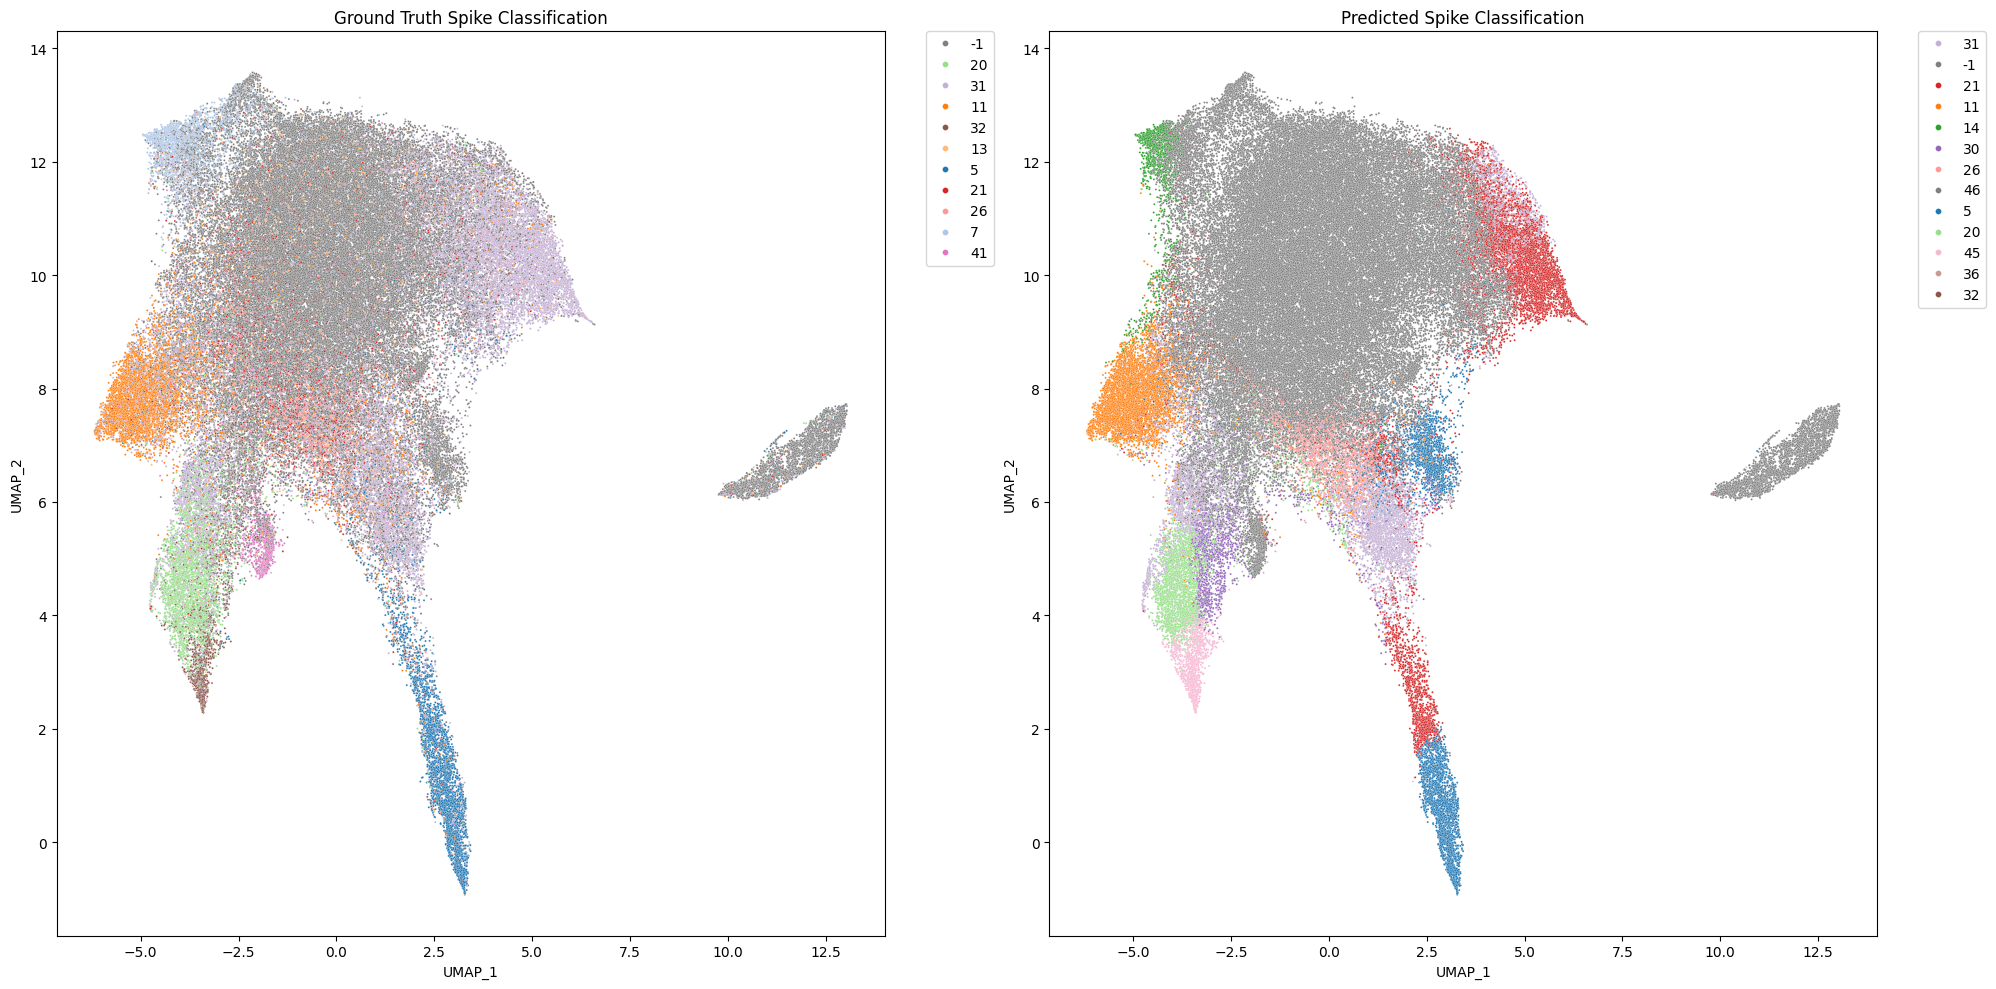

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 创建包含两个子图的画布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# 获取所有可能的类别（并集），并转换为数值进行排序
all_ground_truth = a['ground_truth_spike_classification'].unique()
all_predicted = a['predicted_spike_classification'].unique()
all_classes = np.union1d(all_ground_truth, all_predicted)

# 将-1移到最前面，然后排序其他数值
all_classes_sorted = np.sort(all_classes[all_classes != -1])
all_classes_sorted = np.insert(all_classes_sorted, 0, -1)  # 将-1插入到最前面

# 转换为字符串，用于颜色映射
all_classes_str = [str(cls) for cls in all_classes_sorted]

# 创建统一的颜色映射
palette = {}
tab20_colors = plt.cm.tab20.colors

for i, cls_str in enumerate(all_classes_str):
    if cls_str == '-1':
        palette[cls_str] = 'gray'
    else:
        palette[cls_str] = tab20_colors[(i-1) % len(tab20_colors)]  # 从i-1开始，跳过-1

# 左子图 - 真实标签
sns.scatterplot(x=a['UMAP_1'],
                y=a['UMAP_2'],
                hue=a['ground_truth_spike_classification'].astype(str),
                palette=palette,
                s=2,
                ax=ax1)
ax1.set_title('Ground Truth Spike Classification')
ax1.legend(bbox_to_anchor=(1.05, 1), 
           loc='upper left', 
           borderaxespad=0,
           markerscale=3)

# 右子图 - 预测标签
sns.scatterplot(x=a['UMAP_1'],
                y=a['UMAP_2'],
                hue=a['predicted_spike_classification'].astype(str),
                palette=palette,
                s=2,
                ax=ax2)
ax2.set_title('Predicted Spike Classification')
ax2.legend(bbox_to_anchor=(1.05, 1), 
           loc='upper left', 
           borderaxespad=0,
           markerscale=3)

plt.tight_layout()
plt.show()